# Carry 的平滑周期与季节性诊断

本报告对现有95个品种完整列示，使用可计算的90个品种建立六候选540个观察账户及四个原周期360个对照账户。每个账户初始资金1亿元人民币、16%目标风险、固定资金、单品种权重1、IDM/FDM均为1，保留原生延迟成交、整手、10% buffer和费用。

候选固定为基准10/30/60/125、快周期5/15/30/60、慢周期30/60/125/250，以及基准周期叠加日历月季节项50%、交割组合季节项50%和100%。原生EWM参数为com，span=2×com+1。

季节项只用已完成的历史年份。2021年开始另设冻结对照，候选、模板与幅度系数均在2020年底确定。年度选择以最多10个完整年份的前7年训练、后3年验证；不足时保留baseline。全部结果保留全历史数据审理的事后属性。

In [39]:
%matplotlib inline
import gc
import hashlib
import logging
import time
import warnings
from copy import deepcopy
from pathlib import Path
from contextlib import redirect_stdout
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from threadpoolctl import threadpool_limits
from syscore.constants import arg_not_supplied
from syscore.dateutils import BUSINESS_DAYS_IN_YEAR
from sysdata.config.configdata import Config
from sysdata.data_blob import dataBlob
from sysdata.sim.db_futures_sim_data import dbFuturesSimData, use_sim_classes
from sysobjects.adjusted_prices import futuresAdjustedPrices
from sysobjects.multiple_prices import futuresMultiplePrices
from systems.accounts.curves.account_curve import accountCurve
from systems.accounts.pandl_calculators.pandl_calculation_dict import pandlCalculationWithoutPositions
from syslogging.logger import get_logger

get_logger('carry_diagnostics')
logging.getLogger().setLevel(logging.WARNING)
threadpool_limits(limits=1)
PROJECT = next(p for p in [Path.cwd(), *Path.cwd().parents]
               if (p/'sysdata').is_dir() and (p/'examples/chinese_futures').is_dir())
RESEARCH_CONFIG = PROJECT/'examples/chinese_futures/config'
AUDIT_ROOT = PROJECT/'private/research_runs/carry_breakout_native_2026-09-07'
DATA_ROOT = AUDIT_ROOT/'v2_inputs'
WORK_PARQUET = DATA_ROOT/'parquet'
SHARED = AUDIT_ROOT/'adaptive_shared'
RUN_ROOT = AUDIT_ROOT/'carry_diagnostics'
RUN_ROOT.mkdir(exist_ok=True)
(RUN_ROOT/'figures').mkdir(exist_ok=True)
AS_OF = '2026-09-07'
CUTOFF = pd.Timestamp(AS_OF) + pd.Timedelta(days=1) - pd.Timedelta(nanoseconds=1)
CAPITAL, VOL_TARGET, ANNUAL_DAYS = 100_000_000., 16., BUSINESS_DAYS_IN_YEAR
CANDIDATES = ['baseline','fast','slow','calendar50','pair50','pair100']
PERIODS = {'baseline':[10,30,60,125], 'fast':[5,15,30,60], 'slow':[30,60,125,250],
           'calendar50':[10,30,60,125], 'pair50':[10,30,60,125], 'pair100':[10,30,60,125]}
SLOTS = ['carry10','carry30','carry60','carry125']
mapping = pd.read_csv(PROJECT/'sysdata/tushare/config/futures_instruments.csv')
instruments = sorted(mapping.loc[mapping.StitchMode.eq('stitch'),'Instrument'])
VOL_FLOOR_POINTS = pd.read_csv(RESEARCH_CONFIG/'vol_floor_points.csv', index_col='Instrument').vol_floor_points.to_dict()
trading_windows = pd.read_csv(DATA_ROOT/'trading_windows.csv',parse_dates=['Start','End']).dropna(subset=['Start','End'])
plt.rcParams.update({'font.family':'Arial Unicode MS','axes.grid':True,'grid.alpha':.2,'figure.dpi':110})
pd.set_option('display.max_columns',20)
assert len(instruments)==95 and ANNUAL_DAYS==256
display(pd.DataFrame(PERIODS,index=SLOTS).T)
print('六候选参数已固定；等待同一审核输入导出。')
assert (DATA_ROOT/'volume_diagnostics.parquet').is_file(), '需要2026-09-07冻结输入；准备方法见本目录README。'

,carry10,carry30,carry60,carry125
baseline,10,30,60,125
fast,5,15,30,60
slow,30,60,125,250
calendar50,10,30,60,125
pair50,10,30,60,125
pair100,10,30,60,125


六候选参数已固定；等待同一审核输入导出。


In [2]:
from sysdata.sim.db_futures_sim_data import use_sim_classes
from systems.basesystem import System
from systems.accounts.accounts_stage import Account
from systems.portfolio import Portfolios
from systems.positionsizing import PositionSizing
from systems.rawdata import RawData
from systems.forecast_combine import ForecastCombine
from systems.forecast_scale_cap import ForecastScaleCap
from systems.forecasting import Rules
from systems.system_cache import output, diagnostic
from systems.provided.rules.carry import carry
from systems.provided.rules.breakout import breakout
from sysquant.estimators.vol import mixed_vol_calc

class ResearchData(dbFuturesSimData):
    def __init__(self, windows=arg_not_supplied, end=None):
        self.cutoff = CUTOFF if end is None else pd.Timestamp(end)
        selected = trading_windows if windows is arg_not_supplied else windows
        super().__init__(data=dataBlob(class_list=list(use_sim_classes.values()),
                         parquet_store_path=str(WORK_PARQUET), log_name='portfolio_data',
                         csv_data_paths={'csvRollParametersData':str(DATA_ROOT),
                                         'csvFuturesInstrumentData':str(PROJECT/'data/futures/csvconfig')}),
                         trading_windows=arg_not_supplied if selected is None else selected)

    def get_backadjusted_futures_price(self, instrument_code):
        return futuresAdjustedPrices(super().get_backadjusted_futures_price(instrument_code).loc[:self.cutoff].copy())

    def get_multiple_prices_from_start_date(self, instrument_code, start_date):
        return futuresMultiplePrices(super().get_multiple_prices_from_start_date(instrument_code, start_date).loc[:self.cutoff].copy())

def warmed_breakout(price, lookback=80):
    return breakout(price, lookback=lookback).where(price.notna().cumsum() >= int(np.ceil(lookback / 2)))

class WindowRawData(RawData):
    @output()
    def daily_returns_volatility(self, instrument_code):
        return super().daily_returns_volatility(instrument_code).clip(lower=self.config.vol_floor_points[instrument_code])

RULES = {
    'carry10': {'function': carry, 'data': ['rawdata.raw_carry'], 'other_args': {'smooth_days': 10}},
    'carry30': {'function': carry, 'data': ['rawdata.raw_carry'], 'other_args': {'smooth_days': 30}},
    'carry60': {'function': carry, 'data': ['rawdata.raw_carry'], 'other_args': {'smooth_days': 60}},
    'carry125': {'function': carry, 'data': ['rawdata.raw_carry'], 'other_args': {'smooth_days': 125}},
    'breakout40': {'function': warmed_breakout, 'data': ['rawdata.get_daily_prices'], 'other_args': {'lookback': 40}},
    'breakout80': {'function': warmed_breakout, 'data': ['rawdata.get_daily_prices'], 'other_args': {'lookback': 80}},
    'breakout160': {'function': warmed_breakout, 'data': ['rawdata.get_daily_prices'], 'other_args': {'lookback': 160}},
}
SCALARS = {'carry10': 27.815707053556984, 'carry30': 28.384062881349813,
           'carry60': 28.40072429176199, 'carry125': 29.366474500729886,
           'breakout40': .7036929411910525, 'breakout80': .726260784624834, 'breakout160': .7388310187414805}
WEIGHTS = {
    'carry': {'carry10': .25, 'carry30': .25, 'carry60': .25, 'carry125': .25},
    'breakout': {'breakout40': 1/3, 'breakout80': 1/3, 'breakout160': 1/3},
    'mixed40': {'carry10': .10, 'carry30': .10, 'carry60': .10, 'carry125': .10,
                'breakout40': .20, 'breakout80': .20, 'breakout160': .20},
}
BASE_CONFIG = {
    'forecast_scalars': SCALARS, 'forecast_cap': 20., 'forecast_div_multiplier': 1.,
    'use_forecast_scale_estimates': False, 'use_forecast_weight_estimates': False,
    'use_forecast_div_mult_estimates': False, 'forecast_weight_ewma_span': 1,
    'forecast_post_ceiling_cost_SR': 999999,
    'notional_trading_capital': CAPITAL, 'percentage_vol_target': VOL_TARGET, 'base_currency': 'CNH',
    'capital_multiplier': {'func': 'syscore.capital.full_compounding'},
    'instrument_div_multiplier': 1., 'instrument_weight_ewma_span': 1,
    'use_instrument_weight_estimates': False, 'use_instrument_div_mult_estimates': True,
    'instrument_correlation_estimate': {
        'func': 'sysquant.estimators.correlation_over_time.correlation_over_time_for_returns',
        'frequency': 'W', 'date_method': 'expanding', 'interval_frequency': 'W',
        'using_exponent': True, 'ew_lookback': 25, 'min_periods': 20,
        'cleaning': True, 'rollyears': 20, 'floor_at_zero': True, 'forward_fill_price_index': True,
    },
    'instrument_div_mult_estimate': {
        'func': 'sysquant.estimators.diversification_multipliers.diversification_multiplier_from_list',
        'ewma_span': 125, 'dm_max': 2.5,
    },
    'buffer_method': 'forecast', 'buffer_size': .10, 'buffer_trade_to_edge': True,
    'use_SR_costs': False, 'vol_normalise_currency_costs': False, 'multiply_roll_costs_by': .5,
    'volatility_calculation': {
        'func': 'sysquant.estimators.vol.mixed_vol_calc',
        'name_returns_attr_in_rawdata': 'daily_returns', 'multiplier_to_get_daily_vol': 1.,
        'days': 35, 'min_periods': 10, 'slow_vol_years': 20,
        'proportion_of_slow_vol': .35, 'vol_abs_min': 0., 'backfill': False,
    },
}
BASE_CONFIG['vol_floor_points'] = deepcopy(VOL_FLOOR_POINTS)
assert all(np.isclose(sum(w.values()), 1) for w in WEIGHTS.values())
display(pd.DataFrame(WEIGHTS).fillna(0).join(pd.Series(SCALARS, name='scalar')))
BASE_CONFIG.update({'capital_multiplier':{'func':'syscore.capital.fixed_capital'},
                    'use_instrument_div_mult_estimates':False,'instrument_div_multiplier':1.})

,carry,breakout,mixed40,scalar
carry10,0.25,0.000000,0.1,27.815707
carry30,0.25,0.000000,0.1,28.384063
carry60,0.25,0.000000,0.1,28.400724
carry125,0.25,0.000000,0.1,29.366475
breakout40,0.00,0.333333,0.2,0.703693
breakout80,0.00,0.333333,0.2,0.726261
breakout160,0.00,0.333333,0.2,0.738831


In [3]:
market_frame = pd.read_parquet(SHARED/'market.parquet')
market = {code: frame.droplevel('instrument').copy() for code,frame in market_frame.groupby(level='instrument')}
raw_frame = pd.read_parquet(SHARED/'raw_rules.parquet')
raw_rule_frames = {code:frame.droplevel('instrument').copy() for code,frame in raw_frame.groupby(level='instrument')}
eligibility = pd.read_parquet(SHARED/'eligibility.parquet')
INDEX = eligibility.index
eligible_codes = eligibility.columns.tolist()
metadata = pd.read_csv(SHARED/'metadata.csv',index_col=0)
coverage = pd.read_csv(SHARED/'universe.csv',index_col=0)
assert len(eligible_codes)==90
assert INDEX.max()<=CUTOFF
assert all(market[c].index.is_unique for c in eligible_codes)
display(metadata.head(3))
display(coverage.head(3))
print('可计算品种',len(eligible_codes),'完整列示',len(instruments),'共有输入列',market_frame.columns.tolist())

,Description,Pointsize,Currency,AssetClass,PerBlock,Percentage,PerTrade,Region
Instrument,,,,,,,,
CFFEX_IC,中金所中证五百股指,200.0,CNH,Equity,0.0,0.0,0,ASIA
CFFEX_IF,中金所沪深三百股指,300.0,CNH,Equity,0.0,0.0,0,ASIA
CFFEX_IH,中金所上证五十股指,300.0,CNH,Equity,0.0,0.0,0,ASIA


,description,first,last,observed_days,stored_price_days,windows,raw_vol_median_pct,vol_floor_points,point_size,currency,carry_missing_days,slippage_points,commission_per_contract,commission_bps,commission_per_trade,decision,eligible_decision_days
instrument,,,,,,,,,,,,,,,,,
CFFEX_IC,中金所中证五百股指,2015-05-18,2026-09-07,2751,2751,1,23.259227,27.495000,200.0,CNH,91,0.1,0.0,0.0,0,纳入,2757
CFFEX_IF,中金所沪深三百股指,2010-05-19,2026-09-07,3961,3961,1,18.906471,8.702500,300.0,CNH,128,0.1,0.0,0.0,0,纳入,4020
CFFEX_IH,中金所上证五十股指,2015-05-18,2026-09-07,2751,2751,1,18.089870,9.279375,300.0,CNH,91,0.1,0.0,0.0,0,纳入,2757


可计算品种 90 完整列示 95 共有输入列 ['price', 'adjusted_price', 'returns', 'observed', 'raw_vol_points', 'used_vol_points', 'raw_vol_pct', 'used_vol_pct', 'carry_available', 'window', 'annualised_roll', 'raw_carry', 'PRICE', 'CARRY', 'PRICE_CONTRACT', 'CARRY_CONTRACT', 'roll_differential']


## 季节项与历史信息范围

季节模型使用x=原生年化期限价差/未复权PRICE，随后按原生价格点波动率恢复raw carry。每年模板使用此前全部完整日历年的真实有效报价；训练年份至少120条报价、9个交易月份。每个季节cell至少在3个年份各出现10条报价。按年份等权估计，扣除各年份整体水平，并按训练年份等权中心化至0；未覆盖组合修正为0。候选选择评分才使用最多10年、前7年训练后3年验证。

交割组合键包含交易日历月、PRICE交割月、CARRY交割月和有符号月份距离。不同规格代码分别估计。2021后的冻结版本统一使用2020末模板，此前使用原carry。平滑在审核区间内重新开始。所有候选使用原来的四个scalar和逐rule cap=20；幅度匹配单列诊断，不参与六候选主排名。

In [9]:
candidate_rules = {'annual':{},'frozen':{}}
seasonal_rows, seasonal_status, raw_diagnostics = [], [], []
for instrument in eligible_codes:
    f = market[instrument].copy()
    pc = pd.to_numeric(f.PRICE_CONTRACT,errors='coerce')
    cc = pd.to_numeric(f.CARRY_CONTRACT,errors='coerce')
    pm, cm = (pc//100%100).astype('Int64'), (cc//100%100).astype('Int64')
    gap = ((cc//10000-pc//10000)*12+cm-pm).astype('Int64')
    f['year'] = f.index.year
    f['month_key'] = pd.Series(f.index.month,index=f.index).astype(str)
    f['pair_key'] = f.month_key+'|'+pm.astype(str)+'|'+cm.astype(str)+'|'+gap.astype(str)
    f['x'] = f.annualised_roll/f.price.abs()
    observed = f.observed & f.carry_available & np.isfinite(f.x)
    templates = {}
    for decision_year in sorted(set(f.index.year)|{2021}):
        h = f.loc[observed & f.year.lt(decision_year)].copy()
        year_check = h.groupby('year').agg(days=('x','size'),months=('month_key','nunique'))
        good_years = year_check.index[(year_check.days>=120)&(year_check.months>=9)]
        h = h.loc[h.year.isin(good_years)]
        h['centred'] = h.x-h.groupby('year').x.transform('mean')
        for kind,key_column in [('calendar','month_key'),('pair','pair_key')]:
            cells = h.groupby(['year',key_column]).agg(value=('centred','mean'),days=('x','size'))
            cells = cells.loc[cells.days>=10]
            fitted = cells.groupby(level=1).agg(seasonal=('value','mean'),years=('value','count'),days=('days','sum'))
            fitted = fitted.loc[fitted.years>=3].copy()
            mapped = h[key_column].map(fitted.seasonal)
            coverage_weight = mapped.notna().groupby(h.year).mean().mean()
            centre = mapped.fillna(0).groupby(h.year).mean().mean()/coverage_weight if coverage_weight>0 else 0.
            fitted['seasonal'] -= centre
            if len(fitted):
                assert abs(h[key_column].map(fitted.seasonal).fillna(0).groupby(h.year).mean().mean())<1e-10
            templates[(decision_year,kind)] = fitted.seasonal
            seasonal_status.append(dict(instrument=instrument,decision_year=decision_year,kind=kind,
                training_years=len(good_years),supported_cells=len(fitted),training_end=decision_year-1))
            for key,row in fitted.iterrows():
                seasonal_rows.append(dict(instrument=instrument,decision_year=decision_year,kind=kind,
                    key=key,seasonal=row.seasonal,support_years=row.years,days=row.days,centre=centre))
    inputs = {}
    for mode in ['annual','frozen']:
        corrections = pd.DataFrame(0.,index=f.index,columns=['calendar','pair'])
        for decision_year in sorted(f.year.unique()):
            dates = f.index[f.year.eq(decision_year)]
            template_year = decision_year if mode=='annual' else 2021
            if mode=='frozen' and decision_year<2021:
                continue
            for kind,key_column in [('calendar','month_key'),('pair','pair_key')]:
                table = templates.get((template_year,kind),pd.Series(dtype=float))
                corrections.loc[dates,kind] = f.loc[dates,key_column].map(table).fillna(0.)
        ratio = f.price.abs()/(f.used_vol_points*np.sqrt(ANNUAL_DAYS))
        inputs[mode] = {'baseline':f.raw_carry,'fast':f.raw_carry,'slow':f.raw_carry,
            'calendar50':f.raw_carry-.5*corrections.calendar*ratio,
            'pair50':f.raw_carry-.5*corrections.pair*ratio,
            'pair100':f.raw_carry-corrections.pair*ratio}
        forecast_table = pd.DataFrame(index=f.index)
        for candidate in CANDIDATES:
            for slot,com in zip(SLOTS,PERIODS[candidate]):
                series = pd.Series(np.nan,index=f.index)
                for window in f.window.dropna().unique():
                    dates = f.index[f.window.eq(window)]
                    series.loc[dates] = carry(inputs[mode][candidate].loc[dates],smooth_days=com)
                forecast_table[candidate+'__'+slot] = series
        for slot in SLOTS:
            pd.testing.assert_series_equal(forecast_table['baseline__'+slot],raw_rule_frames[instrument][slot].reindex(f.index),check_names=False)
        candidate_rules[mode][instrument] = forecast_table
    raw_diagnostics.append(f[['x','raw_carry','month_key','pair_key','year']].assign(instrument=instrument))
    if (eligible_codes.index(instrument)+1)%15==0:
        print('季节与平滑候选',eligible_codes.index(instrument)+1,'/',len(eligible_codes),flush=True)
for mode,frames in candidate_rules.items():
    pd.concat(frames,names=['instrument','date']).to_parquet(RUN_ROOT/f'candidate_raw_rules_{mode}.parquet')
pd.DataFrame(seasonal_rows).to_csv(RUN_ROOT/'seasonal_evidence.csv',index=False)
pd.DataFrame(seasonal_status).to_csv(RUN_ROOT/'seasonal_coverage.csv',index=False)
pd.concat(raw_diagnostics).to_parquet(RUN_ROOT/'raw_seasonality_diagnostics.parquet')
display(pd.DataFrame(seasonal_status).groupby('kind').supported_cells.agg(['median','max']))
print('24条raw rule、年度因果版与2020冻结版均已保存。')

季节与平滑候选 15 / 90
季节与平滑候选 30 / 90
季节与平滑候选 45 / 90
季节与平滑候选 60 / 90
季节与平滑候选 75 / 90
季节与平滑候选 90 / 90


,median,max
kind,,
calendar,12.0,12
pair,12.0,23


24条raw rule、年度因果版与2020冻结版均已保存。


In [10]:
from systems.system_cache import output, diagnostic
# 观察账户的必要短阶段：审核区间输入、缺输入空仓、独立固定风险预算。
class DiagnosticRules(Rules):
    @output()
    def get_raw_forecast(self, instrument_code, rule_variation_name):
        return self.parent.config.raw_rules[rule_variation_name].copy()

class DiagnosticRawData(RawData):
    @output()
    def get_daily_prices(self, instrument_code):
        return market[instrument_code].adjusted_price.copy()

    @output()
    def daily_returns(self, instrument_code):
        return market[instrument_code].returns.copy()

    @output()
    def daily_returns_volatility(self, instrument_code):
        return market[instrument_code].used_vol_points.copy()

    @output()
    def daily_denominator_price(self, instrument_code):
        return market[instrument_code].price.copy()

class DiagnosticPortfolio(Portfolios):
    @output()
    def get_instrument_weights(self):
        return self.config.dated_weights.copy()

    @output()
    def get_notional_position(self, instrument_code):
        dates = self.config.dated_weights.index
        position = super().get_notional_position(instrument_code).reindex(dates).ffill()
        return position.where(self.config.dated_weights[instrument_code].gt(0),0.).fillna(0.)

    @output()
    def get_buffers_for_position(self, instrument_code):
        bounds = super().get_buffers_for_position(instrument_code)
        return bounds.where(self.config.dated_weights[instrument_code].reindex(bounds.index).fillna(0).gt(0),0.).fillna(0.)

class DiagnosticCombine(ForecastCombine):
    @diagnostic()
    def cheap_trading_rules_post_processing(self, instrument_code):
        return self.get_trading_rule_list(instrument_code)

shadow_frames, shadow_receipts = {}, []
experiments = CANDIDATES + ['single10','single30','single60','single125']
# 先计算三个边界例子，随后所有品种。始终新建独立System。
jobs = [(candidate,code) for candidate in experiments for code in eligible_codes]
probes = [(candidate,code) for candidate in ['baseline'] for code in ['SHFE_RB','CFFEX_TS','DCE_FB']]
jobs = [j for j in probes if j in jobs] + [j for j in jobs if j not in probes]
for number,(candidate,code) in enumerate(jobs,1):
    started = time.monotonic()
    config = Config(deepcopy(BASE_CONFIG))
    config.instruments = [code]
    config.instrument_weights = {code:1.}
    config.dated_weights = eligibility[[code]].astype(float)
    chosen_slots = ['carry'+candidate.removeprefix('single')] if candidate.startswith('single') else SLOTS
    variant = 'baseline' if candidate.startswith('single') else candidate
    config.forecast_weights = {slot:1/len(chosen_slots) for slot in chosen_slots}
    config.trading_rules = {slot:deepcopy(RULES[slot]) for slot in chosen_slots}
    config.raw_rules = candidate_rules['annual'][code][[variant+'__'+slot for slot in chosen_slots]].rename(
        columns={variant+'__'+slot:slot for slot in chosen_slots})
    with redirect_stdout(StringIO()),warnings.catch_warnings(record=True) as caught:
        system = System([Account(),DiagnosticPortfolio(),PositionSizing(),DiagnosticRawData(),
                         DiagnosticCombine(),ForecastScaleCap(),DiagnosticRules()],ResearchData(),config)
        account = system.accounts.portfolio(delayfill=True,roundpositions=True)
        curve = system.accounts.pandl_for_instrument(code,delayfill=True,roundpositions=True)
        idx = account.index
        held = curve.pandl_calculator_with_costs.positions.reindex(idx).ffill().fillna(0.)
        order = system.accounts.get_buffered_position(code).reindex(idx).ffill().fillna(0.)
        np.testing.assert_allclose(held,order.shift(1).fillna(0.))
        allowed = eligibility[code].reindex(idx).fillna(False).shift(1).fillna(False)
        assert held.loc[~allowed].eq(0).all()
        forecast = system.combForecast.get_combined_forecast(code).reindex(idx)
        frame = pd.DataFrame({'net_pct':account.percent.as_ts,'gross_pct':account.gross.percent.as_ts,
            'cost_pct':account.costs.percent.as_ts,'net_cnh':account.as_ts,
            'held':held,'order':order,'forecast':forecast})
        frame['shadow_equity'] = CAPITAL+frame.net_cnh.cumsum()
        invalid = ~np.isfinite(frame[['net_pct','shadow_equity']]).all(axis=1)|frame.shadow_equity.le(0)
        failure = frame.index[invalid].min()
        frame['valid'] = allowed & (frame.index<failure if pd.notna(failure) else True)
        frame['observed'] = market[code].observed.reindex(idx).fillna(False)
        shadow_frames[(candidate,code)] = frame
        shadow_receipts.append(dict(candidate=candidate,instrument=code,failure=failure,
            observations=int((frame.valid&frame.observed).sum()),seconds=time.monotonic()-started,warnings=len(caught)))
        system.data.data.close()
    del system,account,curve
    if number%30==0 or number<=3:
        gc.collect()
        print('独立固定资金账户',number,'/',len(jobs),candidate,code,flush=True)
shadow = pd.concat(shadow_frames,names=['candidate','instrument','date'])
shadow.to_parquet(RUN_ROOT/'candidate_shadow_returns.parquet')
pd.DataFrame(shadow_receipts).to_csv(RUN_ROOT/'shadow_receipt.csv',index=False)
assert len(shadow_receipts)==900
display(pd.DataFrame(shadow_receipts).groupby('candidate').agg(accounts=('instrument','size'),failures=('failure','count')))
print('六候选540账户，单周期360账户；现金失效后的收益保留原值但不参与评分。')

独立固定资金账户 1 / 291 baseline CZCE_RI
独立固定资金账户 2 / 291 baseline DCE_BB
独立固定资金账户 3 / 291 baseline SHFE_WR
独立固定资金账户 30 / 291 calendar50 CZCE_RI
独立固定资金账户 60 / 291 calendar50 DCE_L
独立固定资金账户 90 / 291 calendar50 SHFE_NI
独立固定资金账户 120 / 291 pair50 CZCE_RI
独立固定资金账户 150 / 291 pair50 DCE_L
独立固定资金账户 180 / 291 pair50 SHFE_NI
独立固定资金账户 210 / 291 pair100 CZCE_RI
独立固定资金账户 240 / 291 pair100 DCE_L
独立固定资金账户 270 / 291 pair100 SHFE_NI


,accounts,failures
candidate,,
baseline,90,5
calendar50,90,2
fast,90,6
pair100,90,2
pair50,90,2
single10,90,6
single125,90,3
single30,90,8
single60,90,4


六候选540账户，单周期360账户；现金失效后的收益保留原值但不参与评分。


## 类别候选选择：预先规定的训练与验证

每个年度生效日前使用最近10个完整日历年，前7年训练、后3年验证。训练至少756、验证至少252个共同有效真实报价；同一经济市场的前身与后继代码按既有资格接续。每个大类至少三个同时合格的经济市场，所有候选使用同一集合和期间。资格计数使用共同有效报价，收益统计保留整段业务日日收益和退出费用。

训练期净Sharpe最高候选相对baseline优势至少0.05，才进入验证；验证期净收益须为正，且净Sharpe至少高于baseline 0.10。任一门槛不满足，采用baseline。各年均记录经济市场数、观察数和回退原因。冻结版使用2020年底的选择，自2021年生效。

In [40]:
classification = pd.read_csv(RESEARCH_CONFIG/'instrument_categories.csv').set_index('Instrument')
assert set(instruments)==set(classification.index)
baseline_reference = pd.read_parquet(SHARED/'shadow_baseline.parquet').xs('carry',level='family').sort_index()
baseline_ours = shadow.xs('baseline',level='candidate').sort_index()
common_rows = baseline_ours.index.intersection(baseline_reference.index)
assert len(common_rows)>0
assert baseline_ours.index.equals(baseline_reference.index), '两份基准日期覆盖须完全一致'
for field in ['net_pct','gross_pct','net_cnh','held','order','forecast']:
    np.testing.assert_allclose(baseline_ours.loc[common_rows,field],
        baseline_reference.loc[common_rows,field],equal_nan=True,atol=1e-8)
print('基准90个原生观察账户与主报告影子逐值核对通过。')

economic_ids = classification.loc[eligible_codes].economic_id.unique()
economic_returns = {}
for candidate in CANDIDATES:
    ticker_returns = shadow.xs(candidate).net_pct.unstack('instrument').reindex(INDEX).fillna(0.)
    economic_returns[candidate] = ticker_returns.T.groupby(classification.loc[ticker_returns.columns,'economic_id']).sum().T
common_observed = pd.concat({candidate:(shadow.xs(candidate).valid & shadow.xs(candidate).observed).unstack('instrument')
    for candidate in CANDIDATES},axis=1).T.groupby(level=1).all().T.reindex(INDEX).fillna(False)
economic_observed = common_observed.T.groupby(classification.loc[common_observed.columns,'economic_id']).any().T
receipt = pd.DataFrame(shadow_receipts)
selection_rows, fold_rows = [], []
first_year = INDEX.min().year
for decision_year in range(first_year,2027):
    train_start,train_end = pd.Timestamp(decision_year-10,1,1),pd.Timestamp(decision_year-4,12,31)
    valid_start,valid_end = pd.Timestamp(decision_year-3,1,1),pd.Timestamp(decision_year-1,12,31)
    for broad in classification.broad.unique():
        economics = classification.loc[classification.broad.eq(broad)&classification.index.isin(eligible_codes),'economic_id'].unique()
        supported = []
        for economic in economics:
            obs = economic_observed[economic]
            train_n,valid_n = int(obs.loc[train_start:train_end].sum()),int(obs.loc[valid_start:valid_end].sum())
            codes = classification.index[classification.economic_id.eq(economic)&classification.index.isin(eligible_codes)]
            failed = receipt.loc[receipt.candidate.isin(CANDIDATES)&receipt.instrument.isin(codes),'failure']
            failed = failed.notna() & failed.le(valid_end)
            accepted = train_n>=756 and valid_n>=252 and not failed.any()
            fold_rows.append(dict(decision_year=decision_year,broad=broad,economic_id=economic,
                train_observations=train_n,valid_observations=valid_n,account_failed=bool(failed.any()),accepted=accepted))
            if accepted:
                supported.append(economic)
        scores = {}
        if len(supported)>=3 and train_start.year>=first_year:
            for candidate in CANDIDATES:
                series = economic_returns[candidate][supported].mean(axis=1)
                scores[candidate] = {}
                for phase,start,end in [('train',train_start,train_end),('validate',valid_start,valid_end)]:
                    pct = series.loc[start:end]
                    curve = accountCurve(pandlCalculationWithoutPositions(pct,pct*0,100.),is_percentage=True)
                    scores[candidate][phase+'_sharpe'] = curve.sharpe()
                    scores[candidate][phase+'_return'] = pct.sum()
            trained = max(CANDIDATES,key=lambda c:scores[c]['train_sharpe'] if np.isfinite(scores[c]['train_sharpe']) else -np.inf)
            chosen,reason = 'baseline','训练优势不足0.05'
            if scores[trained]['train_sharpe']>=scores['baseline']['train_sharpe']+.05:
                if scores[trained]['validate_return']>0 and scores[trained]['validate_sharpe']>=scores['baseline']['validate_sharpe']+.10:
                    chosen,reason = trained,'训练及验证门槛通过'
                else:
                    reason = '验证未达到正净收益及Sharpe优势0.10'
        else:
            trained,chosen,reason = 'baseline','baseline','10年历史或合格经济市场不足3个'
        for candidate in CANDIDATES:
            selection_rows.append(dict(mode='annual',decision_year=decision_year,broad=broad,candidate=candidate,
                selected=candidate==chosen,trained_candidate=trained,reason=reason,markets=len(supported),
                train_start=train_start,train_end=train_end,valid_start=valid_start,valid_end=valid_end,
                **scores.get(candidate,{})))
selection = pd.DataFrame(selection_rows)
folds = pd.DataFrame(fold_rows)
frozen_selection = selection.loc[selection.decision_year.eq(2021)].copy()
frozen_selection['mode'] = 'frozen'
pd.concat([selection,frozen_selection],ignore_index=True).to_csv(RUN_ROOT/'candidate_selection.csv',index=False)
folds.to_csv(RUN_ROOT/'selection_observations.csv',index=False)
display(selection.loc[selection.selected & selection.decision_year.ge(2021),
                      ['decision_year','broad','candidate','markets','reason']])
implemented_rules = {}
for mode in ['annual','frozen']:
    parts = {}
    for code in eligible_codes:
        broad = classification.loc[code,'broad']
        chosen_rules = candidate_rules['annual'][code][['baseline__'+slot for slot in SLOTS]].copy()
        chosen_rules.columns = SLOTS
        for decision_year in sorted(set(chosen_rules.index.year)):
            if mode=='frozen' and decision_year<2021:
                continue
            select_year = decision_year if mode=='annual' else 2021
            row = selection.loc[selection.selected & selection.decision_year.eq(select_year)&selection.broad.eq(broad)]
            candidate = row.candidate.iloc[0] if len(row) else 'baseline'
            dates = chosen_rules.index[chosen_rules.index.year==decision_year]
            chosen_rules.loc[dates] = candidate_rules[mode][code].loc[dates,[candidate+'__'+slot for slot in SLOTS]].to_numpy()
        parts[code] = chosen_rules
    implemented_rules[mode] = parts
    pd.concat(parts,names=['instrument','date']).to_parquet(RUN_ROOT/f'implemented_raw_rules_{mode}.parquet')
print('两版已实施4槽raw rule保存，冻结版2021之前使用baseline。')

基准90个原生观察账户与主报告影子逐值核对通过。


,decision_year,broad,candidate,markets,reason
1560,2021,股指,baseline,1,10年历史或合格经济市场不足3个
1566,2021,利率,baseline,0,10年历史或合格经济市场不足3个
1577,2021,农产品,pair100,9,训练及验证门槛通过
1578,2021,化工,baseline,5,训练优势不足0.05
1584,2021,黑色,baseline,4,验证未达到正净收益及Sharpe优势0.10
1590,2021,林木造纸,baseline,0,10年历史或合格经济市场不足3个
1596,2021,能源,baseline,1,10年历史或合格经济市场不足3个
1602,2021,有色,baseline,4,验证未达到正净收益及Sharpe优势0.10
1608,2021,贵金属,baseline,2,10年历史或合格经济市场不足3个
1614,2021,航运,baseline,0,10年历史或合格经济市场不足3个


两版已实施4槽raw rule保存，冻结版2021之前使用baseline。


In [12]:
# 幅度对照只读取历史forecast，不读取收益；主六候选保留固定scalars。
amplitude_rows, amplitude_rules = [], {'annual':{},'frozen':{}}
amplitude_input = {}
for code in eligible_codes:
    amplitude_input[code] = pd.DataFrame({
        candidate:shadow_frames[(candidate,code)].forecast
        for candidate in ['baseline','fast','slow']}).where(eligibility[code],np.nan)
for decision_year in range(INDEX.min().year,2027):
    prior_means = []
    for code,values in amplitude_input.items():
        history = values.loc[values.index.year<decision_year].dropna()
        if len(history)>=252:
            prior_means.append(history.abs().mean().rename(code))
    means = pd.DataFrame(prior_means)
    for candidate in ['fast','slow']:
        ratio = means.baseline.mean()/means[candidate].mean() if len(means)>=3 else 1.
        assert np.isfinite(ratio) and ratio>0
        amplitude_rows.append(dict(decision_year=decision_year,candidate=candidate,
            ratio=ratio,instruments=len(means),training_end=decision_year-1))
amplitude = pd.DataFrame(amplitude_rows)
amplitude.to_csv(RUN_ROOT/'amplitude_coefficients.csv',index=False)
for mode in ['annual','frozen']:
    for code in eligible_codes:
        result = {}
        for candidate in ['fast','slow']:
            forecasts = candidate_rules['annual'][code][[candidate+'__'+slot for slot in SLOTS]].copy()
            for year in sorted(set(forecasts.index.year)):
                coefficient_year = year if mode=='annual' else min(year,2021)
                ratio = amplitude.loc[amplitude.decision_year.eq(coefficient_year)&amplitude.candidate.eq(candidate),'ratio'].iloc[0]
                forecasts.loc[forecasts.index.year==year] *= ratio
            result[candidate] = forecasts.rename(columns={candidate+'__'+slot:slot for slot in SLOTS})
        amplitude_rules[mode][code] = result
display(amplitude.loc[amplitude.decision_year.ge(2015)])
print('幅度系数采用各品种历史原生合成forecast绝对值的等权平均；冻结版2021起固定2020末系数。')


,decision_year,candidate,ratio,instruments,training_end
40,2015,fast,0.973469,29,2014
41,2015,slow,1.031286,29,2014
42,2016,fast,0.973986,36,2015
43,2016,slow,1.025556,36,2015
44,2017,fast,0.970080,43,2016
45,2017,slow,1.033125,43,2016
46,2018,fast,0.966566,43,2017
47,2018,slow,1.037150,43,2017
48,2019,fast,0.967431,46,2018
49,2019,slow,1.038374,46,2018


幅度系数采用各品种历史原生合成forecast绝对值的等权平均；冻结版2021起固定2020末系数。


In [13]:
implementation_frames, implementation_receipts = {}, []
implementation_jobs = [(mode,code) for mode in ['annual','frozen','amplitude_fast','amplitude_slow'] for code in eligible_codes]
for number,(candidate,code) in enumerate(implementation_jobs,1):
    started = time.monotonic()
    config = Config(deepcopy(BASE_CONFIG))
    config.instruments = [code]
    config.instrument_weights = {code:1.}
    config.dated_weights = eligibility[[code]].astype(float)
    chosen_slots = SLOTS
    config.forecast_weights = {slot:1/len(chosen_slots) for slot in chosen_slots}
    config.trading_rules = {slot:deepcopy(RULES[slot]) for slot in chosen_slots}
    config.raw_rules = (implemented_rules[candidate][code] if candidate in ['annual','frozen']
        else amplitude_rules['annual'][code][candidate.removeprefix('amplitude_')]).copy()
    with redirect_stdout(StringIO()),warnings.catch_warnings(record=True) as caught:
        system = System([Account(),DiagnosticPortfolio(),PositionSizing(),DiagnosticRawData(),
                         DiagnosticCombine(),ForecastScaleCap(),DiagnosticRules()],ResearchData(),config)
        account = system.accounts.portfolio(delayfill=True,roundpositions=True)
        curve = system.accounts.pandl_for_instrument(code,delayfill=True,roundpositions=True)
        idx = account.index
        held = curve.pandl_calculator_with_costs.positions.reindex(idx).ffill().fillna(0.)
        order = system.accounts.get_buffered_position(code).reindex(idx).ffill().fillna(0.)
        np.testing.assert_allclose(held,order.shift(1).fillna(0.))
        allowed = eligibility[code].reindex(idx).fillna(False).shift(1).fillna(False)
        assert held.loc[~allowed].eq(0).all()
        forecast = system.combForecast.get_combined_forecast(code).reindex(idx)
        frame = pd.DataFrame({'net_pct':account.percent.as_ts,'gross_pct':account.gross.percent.as_ts,
            'cost_pct':account.costs.percent.as_ts,'net_cnh':account.as_ts,
            'held':held,'order':order,'forecast':forecast})
        frame['shadow_equity'] = CAPITAL+frame.net_cnh.cumsum()
        invalid = ~np.isfinite(frame[['net_pct','shadow_equity']]).all(axis=1)|frame.shadow_equity.le(0)
        failure = frame.index[invalid].min()
        frame['valid'] = allowed & (frame.index<failure if pd.notna(failure) else True)
        frame['observed'] = market[code].observed.reindex(idx).fillna(False)
        implementation_frames[(candidate,code)] = frame
        implementation_receipts.append(dict(candidate=candidate,instrument=code,failure=failure,
            observations=int((frame.valid&frame.observed).sum()),seconds=time.monotonic()-started,warnings=len(caught)))
        system.data.data.close()
    del system,account,curve
    if number%30==0 or number<=3:
        gc.collect()
        print('重新成交观察账户',number,'/',len(implementation_jobs),candidate,code,flush=True)
    if number in [90,180]:
        mode = 'annual' if number==90 else 'frozen'
        result = pd.concat({code:implementation_frames[(mode,code)] for code in eligible_codes},names=['instrument','date'])
        result.to_parquet(RUN_ROOT/f'implemented_shadow_{mode}.parquet')
        print(mode,'已实施影子及切换成本已保存',flush=True)
implementation_shadow = pd.concat(implementation_frames,names=['candidate','instrument','date'])
implementation_shadow.to_parquet(RUN_ROOT/'implementation_shadow_returns.parquet')
pd.DataFrame(implementation_receipts).to_csv(RUN_ROOT/'implementation_receipt.csv',index=False)
assert len(implementation_receipts)==360
display(pd.DataFrame(implementation_receipts).groupby('candidate').agg(accounts=('instrument','size'),failures=('failure','count')))


重新成交观察账户 1 / 360 annual CFFEX_IC
重新成交观察账户 2 / 360 annual CFFEX_IF
重新成交观察账户 3 / 360 annual CFFEX_IH
重新成交观察账户 30 / 360 annual CZCE_TA
重新成交观察账户 60 / 360 annual DCE_Y
重新成交观察账户 90 / 360 annual SHFE_ZN
annual 已实施影子及切换成本已保存
重新成交观察账户 120 / 360 frozen CZCE_TA
重新成交观察账户 150 / 360 frozen DCE_Y
重新成交观察账户 180 / 360 frozen SHFE_ZN
frozen 已实施影子及切换成本已保存
重新成交观察账户 210 / 360 amplitude_fast CZCE_TA
重新成交观察账户 240 / 360 amplitude_fast DCE_Y
重新成交观察账户 270 / 360 amplitude_fast SHFE_ZN
重新成交观察账户 300 / 360 amplitude_slow CZCE_TA
重新成交观察账户 330 / 360 amplitude_slow DCE_Y
重新成交观察账户 360 / 360 amplitude_slow SHFE_ZN


,accounts,failures
candidate,,
amplitude_fast,90,6
amplitude_slow,90,4
annual,90,4
frozen,90,3


## 结果的统计单位

观察账户每个交易日按 1 亿元固定风险预算生成手数。净收益、毛收益和成本由原生账户给出，日收益单位为初始资金的百分点；原生 Sharpe 和年化波动率使用每年 256 个业务日。累计收益回撤列的单位也是百分点。另列真实固定资金净值 `1 + 累计现金盈亏 / 初始资金` 的峰值回撤百分比。

每个品种完整可计算历史从首次可交易日开始，保留该段全部原生现金流和退出成本。失败日证据单列，正常统计截止失败前。固定资金账户的净值路径用于检查偿付能力。年度类别选择只按训练、验证规则执行，逐品种的最优历史候选只用于诊断。

幅度对照用此前完整年份中原生实际合成 forecast 的平均绝对值，先在每个品种内求均值，再对品种等权求均值。系数作用于各条原始 rule，仍经过原生逐 rule cap 和最终 cap；表中检查实际匹配残差、成本和净绩效。幅度绩效对照使用年度因果系数。

对于稻米、胶合板和线材三个短历史品种，单品种系统的自动规则费用估计出现空值。本研究固定使用已声明的规则列表，固定权重后交给原生缓冲、成交与费用模块。

In [20]:
all_frames = {**shadow_frames,**implementation_frames}
all_receipts = pd.concat([pd.DataFrame(shadow_receipts),pd.DataFrame(implementation_receipts)],ignore_index=True)
metric_rows, failure_rows = [], []
common_failure = all_receipts.groupby('instrument').failure.min()
periods = [('完整历史',None,None),('2011—2020','2011-01-01','2020-12-31'),('2021以后','2021-01-01',AS_OF),
    ('14候选共同历史',None,None),('14候选共同2021以后','2021-01-01',AS_OF)]
for (candidate,code),frame in all_frames.items():
    receipt_row = all_receipts.loc[all_receipts.candidate.eq(candidate)&all_receipts.instrument.eq(code)].iloc[0]
    failure = receipt_row.failure
    active_dates = frame.index[eligibility[code].reindex(frame.index).fillna(False).shift(1).fillna(False)]
    if len(active_dates)==0:
        continue
    first = active_dates.min()
    # 整个原生现金流尾部保留，含审核窗口结束后的平仓成本。
    last_flow = frame.index[(frame.net_cnh.fillna(0).ne(0)|frame.held.ne(0))]
    last = max(active_dates.max(),last_flow.max()) if len(last_flow) else active_dates.max()
    if pd.notna(failure):
        failure_rows.append(dict(candidate=candidate,instrument=code,date=failure,**frame.loc[failure].to_dict()))
        last = min(last,failure-pd.offsets.BDay())
    for period,start,end in periods:
        left = max(first,pd.Timestamp(start)) if start else first
        right = min(last,pd.Timestamp(end)) if end else last
        if period.startswith('14候选共同') and pd.notna(common_failure[code]):
            right = min(right,common_failure[code]-pd.offsets.BDay())
        part = frame.loc[left:right].copy()
        if len(part)<2:
            continue
        pct = part.net_pct.fillna(0.)
        gross = part.gross_pct.fillna(0.)
        cost = part.cost_pct.fillna(0.)
        native = accountCurve(pandlCalculationWithoutPositions(gross,cost,100.),is_percentage=True)
        np.testing.assert_allclose(native.as_ts,pct,atol=1e-9)
        annual_vol = native.ann_std()
        gross_vol = native.gross.ann_std()
        wealth = 1+pct.cumsum()/100
        peak = wealth.cummax().clip(lower=1.)
        held_days = part.held.ne(0)
        decision_eligible = eligibility[code].reindex(part.index).fillna(False)
        combined = part.forecast.loc[decision_eligible].dropna()
        turnovers = part.order.diff().abs().fillna(part.order.abs())
        metric_rows.append(dict(candidate=candidate,instrument=code,description=classification.loc[code,'Description'],
            broad=classification.loc[code,'broad'],period=period,start=part.index.min(),end=part.index.max(),
            days=len(part),observations=int((part.valid&part.observed).sum()),net_sharpe=native.sharpe() if annual_vol>0 else np.nan,
            gross_sharpe=native.gross.sharpe() if gross_vol>0 else np.nan,annual_return_pct=native.ann_mean(),annual_vol_pct=annual_vol,
            net_return_pct=pct.sum(),cost_pct=cost.sum(),worst_day_pct=pct.min(),
            native_drawdown_pp=native.worst_drawdown(),equity_drawdown_pct=(wealth/peak-1).min()*100,
            ending_fixed_equity=wealth.iloc[-1],forecast_abs=combined.abs().mean(),
            forecast_cap_share=combined.abs().ge(20-1e-8).mean(),holding_share=held_days.mean(),
            traded_contracts=turnovers.sum(),failure=failure))
metrics = pd.DataFrame(metric_rows)
metrics.to_csv(RUN_ROOT/'instrument_metrics.csv',index=False)
pd.DataFrame(failure_rows).to_csv(RUN_ROOT/'account_failure_evidence.csv',index=False)
summary = metrics.loc[metrics.period.eq('2021以后')].groupby('candidate').agg(
    instruments=('instrument','size'),median_sharpe=('net_sharpe','median'),
    median_forecast_abs=('forecast_abs','median'),median_annual_vol=('annual_vol_pct','median'),
    median_cost_pct=('cost_pct','median'))
display(summary.round(3))
display(metrics.loc[metrics.period.eq('完整历史')&metrics.candidate.isin(['single10','single30','single60','single125'])].groupby('candidate')[
    ['net_sharpe','forecast_abs','annual_vol_pct','cost_pct','traded_contracts']].median().round(3))


,instruments,median_sharpe,median_forecast_abs,median_annual_vol,median_cost_pct
candidate,,,,,
amplitude_fast,75,0.173,9.247,17.858,-0.261
amplitude_slow,76,0.164,8.356,16.186,-0.199
annual,75,0.213,8.762,16.227,-0.247
baseline,75,0.185,8.841,16.819,-0.233
calendar50,77,0.207,8.820,16.294,-0.246
fast,75,0.179,9.494,18.027,-0.264
frozen,75,0.196,8.762,16.227,-0.247
pair100,77,0.213,8.917,16.993,-0.258
pair50,77,0.211,8.821,16.358,-0.252


,net_sharpe,forecast_abs,annual_vol_pct,cost_pct,traded_contracts
candidate,,,,,
single10,0.287,10.750,20.980,-0.941,61068.5
single125,0.198,9.730,18.008,-0.500,26776.0
single30,0.253,10.719,20.129,-0.677,40005.5
single60,0.218,10.330,19.329,-0.569,31425.0


In [28]:
# 将月份组合、历史覆盖与公平期间绩效合并，逐一列明95品种。
evidence = coverage.copy()
evidence['broad'] = classification.broad
evidence['economic_id'] = classification.economic_id
common_metrics = metrics.loc[metrics.period.eq('14候选共同历史')]
for candidate in CANDIDATES+['amplitude_fast','amplitude_slow']:
    rows = common_metrics.loc[common_metrics.candidate.eq(candidate)].set_index('instrument')
    for field in ['net_sharpe','annual_return_pct','forecast_abs','cost_pct']:
        evidence[f'{candidate}_{field}'] = rows[field]
season_coverage = pd.DataFrame(seasonal_status)
latest_season = season_coverage.loc[season_coverage.decision_year.eq(2026)]
for kind in ['calendar','pair']:
    rows = latest_season.loc[latest_season.kind.eq(kind)].set_index('instrument')
    evidence[kind+'_supported_cells'] = rows.supported_cells
    evidence[kind+'_training_years'] = rows.training_years
evidence['baseline_failure'] = all_receipts.loc[all_receipts.candidate.eq('baseline')].set_index('instrument').failure
evidence['joint_end_failure'] = common_failure
evidence['fast_delta_sharpe'] = evidence.fast_net_sharpe-evidence.baseline_net_sharpe
evidence['slow_delta_sharpe'] = evidence.slow_net_sharpe-evidence.baseline_net_sharpe
evidence['pair100_delta_sharpe'] = evidence.pair100_net_sharpe-evidence.baseline_net_sharpe
evidence['diagnosis'] = evidence.decision.astype(str)
for code in eligible_codes:
    row = evidence.loc[code]
    notes = []
    if pd.notna(row.baseline_failure):
        notes.append('固定观察账户曾失效，正常比较在共同失效前截止')
    if row.carry_missing_days>0:
        notes.append(f'carry缺报价{int(row.carry_missing_days)}日')
    if row.eligible_decision_days<252:
        notes.append('可交易观察不足252日')
    if pd.isna(row.pair_supported_cells) or row.pair_supported_cells==0:
        notes.append('月份组合季节模板支持不足，修正回落为0')
    else:
        notes.append(f'月份组合模板支持{int(row.pair_supported_cells)}格')
    evidence.loc[code,'diagnosis']='；'.join(notes)
evidence.to_csv(RUN_ROOT/'instrument_evidence.csv')
with pd.option_context('display.max_rows',100,'display.max_colwidth',100):
    display(evidence[['description','broad','decision','baseline_net_sharpe','fast_delta_sharpe',
        'slow_delta_sharpe','pair100_delta_sharpe','diagnosis']])
response_rows = []
for code in eligible_codes:
    mask = eligibility[code]
    for candidate in ['baseline','fast','slow','single10','single30','single60','single125','amplitude_fast','amplitude_slow']:
        series = all_frames[(candidate,code)].forecast.where(mask)
        values = series.dropna()
        signs = np.sign(series)
        response_rows.append(dict(instrument=code,candidate=candidate,mean_abs_forecast=values.abs().mean(),
            lag1_autocorrelation=series.autocorr() if values.std()>0 else np.nan,long_share=values.gt(0).mean(),
            sign_changes=int(signs.diff().abs().gt(0).sum()),cap_share=values.abs().ge(20-1e-8).mean()))
response = pd.DataFrame(response_rows)
baseline_amplitude = response.loc[response.candidate.eq('baseline')].set_index('instrument').mean_abs_forecast
response['ratio_to_baseline'] = response.mean_abs_forecast/response.instrument.map(baseline_amplitude)
response['absolute_gap_to_baseline'] = response.mean_abs_forecast-response.instrument.map(baseline_amplitude)
response.to_csv(RUN_ROOT/'smoothing_response.csv',index=False)
display(response.groupby('candidate')[['mean_abs_forecast','lag1_autocorrelation','sign_changes','cap_share','ratio_to_baseline','absolute_gap_to_baseline']].median().round(4))


,description,broad,decision,baseline_net_sharpe,fast_delta_sharpe,slow_delta_sharpe,pair100_delta_sharpe,diagnosis
instrument,,,,,,,,
CFFEX_IC,中金所中证五百股指,股指,纳入,0.797382,0.044256,-0.079377,0.006241,carry缺报价91日；月份组合模板支持19格
CFFEX_IF,中金所沪深三百股指,股指,纳入,0.655436,0.009188,-0.028988,-0.031733,carry缺报价128日；月份组合模板支持21格
CFFEX_IH,中金所上证五十股指,股指,纳入,0.659135,0.016128,0.007638,0.059416,carry缺报价91日；月份组合模板支持19格
CFFEX_IM,中金所中证一千股指,股指,纳入,0.778437,-0.022542,0.006245,0.002297,carry缺报价45日；月份组合模板支持9格
CFFEX_T,中金所十年期国债,利率,低波动剔除,NaN,NaN,NaN,NaN,低波动剔除
CFFEX_TF,中金所五年期国债,利率,低波动剔除,NaN,NaN,NaN,NaN,低波动剔除
CFFEX_TL,中金所三十年期国债,利率,纳入,1.277561,-0.097899,0.090616,0.000000,月份组合季节模板支持不足，修正回落为0
CFFEX_TS,中金所两年期国债,利率,低波动剔除,NaN,NaN,NaN,NaN,低波动剔除
CZCE_AP,郑商所苹果,农产品,纳入,0.704172,0.124200,-0.198485,0.024446,carry缺报价5日；月份组合模板支持14格


/Users/z/PycharmProjects/pysystemtrade/.venv/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/z/PycharmProjects/pysystemtrade/.venv/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,mean_abs_forecast,lag1_autocorrelation,sign_changes,cap_share,ratio_to_baseline,absolute_gap_to_baseline
candidate,,,,,,
amplitude_fast,10.3762,0.9992,11.5,0.0778,1.0209,0.1971
amplitude_slow,9.7699,0.9998,4.0,0.0312,0.9821,-0.1681
baseline,10.2489,0.9996,7.5,0.0402,1.0000,0.0000
fast,10.5550,0.9992,11.5,0.0874,1.0410,0.3443
single10,10.6483,0.9986,17.0,0.2003,1.0741,0.6390
single125,9.7462,0.9999,3.0,0.0653,0.9973,-0.0202
single30,10.7183,0.9995,8.5,0.1718,1.0584,0.4698
single60,10.2112,0.9998,5.0,0.1310,1.0185,0.1820
slow,9.5635,0.9998,4.0,0.0233,0.9590,-0.3533


In [22]:
# 月度现金流保留退出成本；合约列表示当日PRICE/CARRY报价对应的交割月份。
monthly_parts = []
for code in eligible_codes:
    frame = shadow_frames[('baseline',code)]
    f = market[code].reindex(frame.index)
    part = frame[['net_pct','gross_pct','cost_pct','forecast','held']].copy()
    part['PRICE_CONTRACT'] = f.PRICE_CONTRACT.ffill()
    part['CARRY_CONTRACT'] = f.CARRY_CONTRACT.ffill()
    part['observed'] = f.observed.fillna(False).astype(int)
    part['raw_carry'] = f.raw_carry
    part['roll_yield_pct'] = f.annualised_roll/f.price.abs()*100
    part['executed_contract_changes'] = frame.held.diff().abs().fillna(0.)
    part['year'],part['month'] = part.index.year,part.index.month
    failure = all_receipts.loc[all_receipts.candidate.eq('baseline')&all_receipts.instrument.eq(code),'failure'].iloc[0]
    if pd.notna(failure):
        part = part.loc[part.index<failure]
    grouped = part.groupby(['year','month','PRICE_CONTRACT','CARRY_CONTRACT']).agg(
        observations=('observed','sum'),net_pct=('net_pct','sum'),gross_pct=('gross_pct','sum'),
        cost_pct=('cost_pct','sum'),mean_forecast=('forecast','mean'),mean_raw_carry=('raw_carry','mean'),
        mean_roll_yield_pct=('roll_yield_pct','mean'),executed_contract_changes=('executed_contract_changes','sum'))
    grouped = grouped.loc[grouped.observations.gt(0)|grouped.net_pct.ne(0)|grouped.cost_pct.ne(0)]
    grouped['instrument']=code
    monthly_parts.append(grouped.reset_index())
monthly_evidence = pd.concat(monthly_parts,ignore_index=True)
monthly_evidence.to_csv(RUN_ROOT/'monthly_contract_evidence.csv',index=False)
annual_evidence = monthly_evidence.groupby(['instrument','year'])[['net_pct','gross_pct','cost_pct','observations']].sum().reset_index()
annual_evidence.to_csv(RUN_ROOT/'annual_carry_evidence.csv',index=False)
baseline_full = metrics.loc[metrics.candidate.eq('baseline')&metrics.period.eq('完整历史')].set_index('instrument')
loss_rows = []
for code,row in baseline_full.loc[baseline_full.net_return_pct.lt(0)].iterrows():
    annual = annual_evidence.loc[annual_evidence.instrument.eq(code)]
    worst = annual.loc[annual.net_pct.idxmin()]
    months = monthly_evidence.loc[monthly_evidence.instrument.eq(code)]
    bad_month = months.loc[months.net_pct.idxmin()]
    common = evidence.loc[code]
    gross_total = row.net_return_pct-row.cost_pct
    accounting = '毛收益为负' if gross_total<0 else '费用超过正毛收益'
    reason = (f'{accounting}；净现金收益{row.net_return_pct:.1f}百分点，毛收益{gross_total:.1f}、成本{row.cost_pct:.1f}。'
        f'最差年度{int(worst.year)}年为{worst.net_pct:.1f}百分点；最差合约月段{int(bad_month.year)}年{int(bad_month.month)}月，'
        f'PRICE {int(bad_month.PRICE_CONTRACT)//100} / CARRY {int(bad_month.CARRY_CONTRACT)//100}，净收益{bad_month.net_pct:.1f}百分点。'
        f'共同期快速、慢速、月份组合100%净Sharpe变化分别为{common.fast_delta_sharpe:+.2f}、{common.slow_delta_sharpe:+.2f}、{common.pair100_delta_sharpe:+.2f}。')
    loss_rows.append(dict(instrument=code,description=classification.loc[code,'Description'],reason=reason))
loss_diagnoses = pd.DataFrame(loss_rows)
loss_diagnoses.to_csv(RUN_ROOT/'loss_instrument_diagnoses.csv',index=False)
display(Markdown('\n\n'.join(f"**{row.description}（{row.instrument}）**：{row.reason}" for row in loss_diagnoses.itertuples())))
display(monthly_evidence.loc[monthly_evidence.instrument.isin(['DCE_A','DCE_C','CZCE_CY','CZCE_TA'])].sort_values('net_pct').head(20))


**郑商所早籼稻（旧合约）（CZCE_ER）**：毛收益为负；净现金收益-19.9百分点，毛收益-11.9、成本-7.9。最差年度2012年为-27.5百分点；最差合约月段2010年10月，PRICE 201105 / CARRY 201101，净收益-29.8百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为+0.05、-0.05、+0.00。

**郑商所晚籼稻（CZCE_LR）**：毛收益为负；净现金收益-2.6百分点，毛收益-1.8、成本-0.9。最差年度2019年为-2.7百分点；最差合约月段2019年2月，PRICE 201903 / CARRY 201905，净收益-4.0百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为+0.11、-0.16、+0.00。

**郑商所甲醇（CZCE_MA）**：毛收益为负；净现金收益-80.5百分点，毛收益-79.7、成本-0.8。最差年度2018年为-37.2百分点；最差合约月段2018年11月，PRICE 201901 / CARRY 201905，净收益-22.2百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为+0.07、-0.04、-0.03。

**郑商所短纤（CZCE_PF）**：毛收益为负；净现金收益-10.1百分点，毛收益-10.0、成本-0.1。最差年度2022年为-5.3百分点；最差合约月段2026年3月，PRICE 202605 / CARRY 202609，净收益-5.3百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为+0.02、+0.11、+0.02。

**郑商所花生（CZCE_PK）**：毛收益为负；净现金收益-61.3百分点，毛收益-60.7、成本-0.6。最差年度2023年为-25.6百分点；最差合约月段2022年5月，PRICE 202210 / CARRY 202211，净收益-16.0百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为-0.08、+0.07、+0.18。

**郑商所丙烯（CZCE_PL）**：毛收益为负；净现金收益-10.6百分点，毛收益-10.4、成本-0.2。最差年度2026年为-11.0百分点；最差合约月段2026年3月，PRICE 202604 / CARRY 202605，净收益-25.3百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为+0.11、-0.22、+0.00。

**郑商所菜籽油（旧合约）（CZCE_RO）**：毛收益为负；净现金收益-5.9百分点，毛收益-5.2、成本-0.6。最差年度2010年为-12.7百分点；最差合约月段2008年3月，PRICE 200809 / CARRY 200901，净收益-21.9百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为+0.18、-0.21、+0.02。

**郑商所纯碱（CZCE_SA）**：毛收益为负；净现金收益-24.7百分点，毛收益-24.3、成本-0.4。最差年度2021年为-71.5百分点；最差合约月段2021年9月，PRICE 202201 / CARRY 202205，净收益-32.8百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为-0.34、+0.45、+0.00。

**郑商所锰硅（CZCE_SM）**：毛收益为负；净现金收益-16.7百分点，毛收益-16.4、成本-0.3。最差年度2019年为-15.1百分点；最差合约月段2018年11月，PRICE 201901 / CARRY 201905，净收益-13.7百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为-0.02、+0.12、+0.00。

**郑商所精对苯二甲酸（CZCE_TA）**：毛收益为负；净现金收益-95.1百分点，毛收益-94.5、成本-0.6。最差年度2008年为-76.1百分点；最差合约月段2010年11月，PRICE 201101 / CARRY 201105，净收益-27.6百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为+0.02、+0.25、+0.00。

**郑商所强筋小麦（CZCE_WH）**：毛收益为负；净现金收益-24.4百分点，毛收益-3.1、成本-21.3。最差年度2016年为-38.9百分点；最差合约月段2016年4月，PRICE 201605 / CARRY 201609，净收益-33.4百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为+0.01、-0.03、+0.16。

**大商所黄大豆一号（DCE_A）**：毛收益为负；净现金收益-95.9百分点，毛收益-93.9、成本-2.0。最差年度2007年为-90.0百分点；最差合约月段2008年8月，PRICE 200809 / CARRY 200901，净收益-54.0百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为-0.12、+0.05、+0.36。

**大商所黄大豆二号（DCE_B）**：毛收益为负；净现金收益-9.8百分点，毛收益-8.7、成本-1.0。最差年度2018年为-21.6百分点；最差合约月段2019年5月，PRICE 201909 / CARRY 202001，净收益-19.5百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为-0.02、+0.02、+0.05。

**大商所纯苯（DCE_BZ）**：毛收益为负；净现金收益-23.3百分点，毛收益-23.1、成本-0.2。最差年度2026年为-23.1百分点；最差合约月段2026年3月，PRICE 202604 / CARRY 202605，净收益-28.3百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为-0.07、+0.15、+0.00。

**大商所玉米（DCE_C）**：毛收益为负；净现金收益-98.2百分点，毛收益-89.6、成本-8.5。最差年度2020年为-73.5百分点；最差合约月段2006年11月，PRICE 200701 / CARRY 200705，净收益-31.4百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为+0.00、+0.01、+0.07。

**大商所玉米淀粉（DCE_CS）**：毛收益为负；净现金收益-99.3百分点，毛收益-98.2、成本-1.0。最差年度2020年为-44.0百分点；最差合约月段2020年7月，PRICE 202009 / CARRY 202101，净收益-19.1百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为-0.08、+0.09、-0.04。

**大商所苯乙烯（DCE_EB）**：毛收益为负；净现金收益-10.6百分点，毛收益-10.3、成本-0.3。最差年度2020年为-31.6百分点；最差合约月段2026年3月，PRICE 202604 / CARRY 202603，净收益-22.0百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为+0.09、-0.12、+0.08。

**大商所乙二醇（DCE_EG）**：毛收益为负；净现金收益-9.1百分点，毛收益-8.9、成本-0.2。最差年度2021年为-12.2百分点；最差合约月段2026年3月，PRICE 202605 / CARRY 202609，净收益-16.1百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为+0.14、-0.15、+0.04。

**广期所钯（GFEX_PD）**：毛收益为负；净现金收益-0.1百分点，毛收益-0.1、成本-0.0。最差年度2026年为-0.1百分点；最差合约月段2026年8月，PRICE 202610 / CARRY 202612，净收益-0.3百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为+0.38、-0.39、+0.00。

**广期所铂（GFEX_PT）**：毛收益为负；净现金收益-0.1百分点，毛收益-0.1、成本-0.0。最差年度2026年为-0.1百分点；最差合约月段2026年8月，PRICE 202610 / CARRY 202612，净收益-0.1百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为+0.71、+nan、+0.00。

**上海能源国际铜（INE_BC）**：毛收益为负；净现金收益-4.6百分点，毛收益-4.4、成本-0.1。最差年度2025年为-7.2百分点；最差合约月段2024年4月，PRICE 202406 / CARRY 202407，净收益-3.9百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为-0.11、+0.26、-0.12。

**上海能源二十号胶（INE_NR）**：毛收益为负；净现金收益-88.9百分点，毛收益-87.9、成本-1.0。最差年度2024年为-29.9百分点；最差合约月段2024年9月，PRICE 202411 / CARRY 202410，净收益-18.1百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为-0.01、+0.08、+0.02。

**上海能源原油（INE_SC）**：毛收益为负；净现金收益-23.8百分点，毛收益-23.4、成本-0.4。最差年度2021年为-28.4百分点；最差合约月段2021年2月，PRICE 202104 / CARRY 202103，净收益-17.2百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为+0.17、-0.15、+0.11。

**上期所氧化铝（SHFE_AO）**：毛收益为负；净现金收益-2.9百分点，毛收益-2.8、成本-0.2。最差年度2025年为-39.2百分点；最差合约月段2025年1月，PRICE 202502 / CARRY 202505，净收益-25.9百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为+0.28、-0.31、+0.00。

**上期所黄金（SHFE_AU）**：毛收益为负；净现金收益-70.3百分点，毛收益-70.3、成本-0.1。最差年度2025年为-29.3百分点；最差合约月段2019年6月，PRICE 201912 / CARRY 202006，净收益-8.8百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为+0.02、-0.02、+0.00。

**上期所丁二烯橡胶（SHFE_BR）**：毛收益为负；净现金收益-7.7百分点，毛收益-7.5、成本-0.1。最差年度2026年为-5.5百分点；最差合约月段2026年3月，PRICE 202604 / CARRY 202603，净收益-4.7百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为-0.04、+0.20、+0.00。

**上期所燃料油（SHFE_FU）**：毛收益为负；净现金收益-2.8百分点，毛收益-2.5、成本-0.3。最差年度2025年为-12.8百分点；最差合约月段2026年6月，PRICE 202609 / CARRY 202701，净收益-11.4百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为+0.05、-0.02、+0.01。

**上期所镍（SHFE_NI）**：毛收益为负；净现金收益-6.6百分点，毛收益-6.6、成本-0.0。最差年度2023年为-23.4百分点；最差合约月段2023年5月，PRICE 202309 / CARRY 202401，净收益-9.7百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为+0.07、-0.09、+0.05。

**上期所天然橡胶（SHFE_RU）**：毛收益为负；净现金收益-97.8百分点，毛收益-95.6、成本-2.2。最差年度2009年为-34.1百分点；最差合约月段2003年4月，PRICE 200305 / CARRY 200309，净收益-37.2百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为+0.02、-0.04、+0.04。

**上期所纸浆（SHFE_SP）**：毛收益为负；净现金收益-45.8百分点，毛收益-45.1、成本-0.7。最差年度2023年为-45.4百分点；最差合约月段2020年12月，PRICE 202101 / CARRY 202105，净收益-35.7百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为+0.05、-0.07、-0.01。

**上期所线材（SHFE_WR）**：毛收益为负；净现金收益-12.1百分点，毛收益-11.7、成本-0.4。最差年度2010年为-12.1百分点；最差合约月段2010年3月，PRICE 201005 / CARRY 201010，净收益-14.5百分点。共同期快速、慢速、月份组合100%净Sharpe变化分别为+0.07、-0.09、+0.00。

,year,month,PRICE_CONTRACT,CARRY_CONTRACT,observations,net_pct,gross_pct,cost_pct,mean_forecast,mean_raw_carry,mean_roll_yield_pct,executed_contract_changes,instrument
4572,2008,8,20080900,20090100,11,-53.983805,-53.97257,-0.011235,20.000000,1.450174,28.048375,2247.0,DCE_A
4798,2006,11,20070100,20070500,22,-31.406580,-31.35710,-0.049480,-20.000000,-2.121235,-22.988917,9896.0,DCE_C
4511,2004,7,20040900,20050100,22,-27.762160,-27.75477,-0.007390,20.000000,1.611267,32.330245,1478.0,DCE_A
3807,2010,11,20110100,20110500,7,-27.568290,-27.56199,-0.006300,-17.757887,-0.662759,-12.482567,1260.0,CZCE_TA
4927,2015,6,20150900,20160100,21,-26.793310,-26.76067,-0.032640,19.977805,3.427050,29.583299,6528.0,DCE_C
5003,2020,7,20200900,20210100,23,-26.020035,-25.96094,-0.059095,-13.330065,0.211581,2.602272,11819.0,DCE_C
4848,2010,3,20100500,20100900,23,-25.519929,-25.41488,-0.105049,-20.000000,-0.959907,-5.709356,8936.0,DCE_C
4444,2000,1,20000500,20000900,18,-24.386775,-24.35812,-0.028655,-20.000000,-2.753387,-26.448456,5731.0,DCE_A
5063,2024,7,20240900,20250100,23,-20.658090,-20.65005,-0.008040,17.525844,1.153926,9.579551,1608.0,DCE_C
4558,2007,8,20080100,20080500,12,-20.354680,-20.35060,-0.004080,-20.000000,-0.569975,-6.396967,816.0,DCE_A


逐品种图页 15 / 95
逐品种图页 30 / 95
逐品种图页 45 / 95
逐品种图页 60 / 95
逐品种图页 75 / 95
逐品种图页 90 / 95


,instrument,description,decision,path
0,CFFEX_IC,中金所中证五百股指,纳入,/Users/z/PycharmProjects/pysystemtrade/private/research_runs/carry_breakout_native_2026-09-07/carry_diagnostics/figures/CFFEX_IC.png
1,CFFEX_IF,中金所沪深三百股指,纳入,/Users/z/PycharmProjects/pysystemtrade/private/research_runs/carry_breakout_native_2026-09-07/carry_diagnostics/figures/CFFEX_IF.png
2,CFFEX_IH,中金所上证五十股指,纳入,/Users/z/PycharmProjects/pysystemtrade/private/research_runs/carry_breakout_native_2026-09-07/carry_diagnostics/figures/CFFEX_IH.png
3,CFFEX_IM,中金所中证一千股指,纳入,/Users/z/PycharmProjects/pysystemtrade/private/research_runs/carry_breakout_native_2026-09-07/carry_diagnostics/figures/CFFEX_IM.png
4,CFFEX_T,中金所十年期国债,低波动剔除,/Users/z/PycharmProjects/pysystemtrade/private/research_runs/carry_breakout_native_2026-09-07/carry_diagnostics/figures/CFFEX_T.png
5,CFFEX_TF,中金所五年期国债,低波动剔除,/Users/z/PycharmProjects/pysystemtrade/private/research_runs/carry_breakout_native_2026-09-07/carry_diagnostics/figures/CFFEX_TF.png
6,CFFEX_TL,中金所三十年期国债,纳入,/Users/z/PycharmProjects/pysystemtrade/private/research_runs/carry_breakout_native_2026-09-07/carry_diagnostics/figures/CFFEX_TL.png
7,CFFEX_TS,中金所两年期国债,低波动剔除,/Users/z/PycharmProjects/pysystemtrade/private/research_runs/carry_breakout_native_2026-09-07/carry_diagnostics/figures/CFFEX_TS.png
8,CZCE_AP,郑商所苹果,纳入,/Users/z/PycharmProjects/pysystemtrade/private/research_runs/carry_breakout_native_2026-09-07/carry_diagnostics/figures/CZCE_AP.png
9,CZCE_CF,郑商所棉花,纳入,/Users/z/PycharmProjects/pysystemtrade/private/research_runs/carry_breakout_native_2026-09-07/carry_diagnostics/figures/CZCE_CF.png


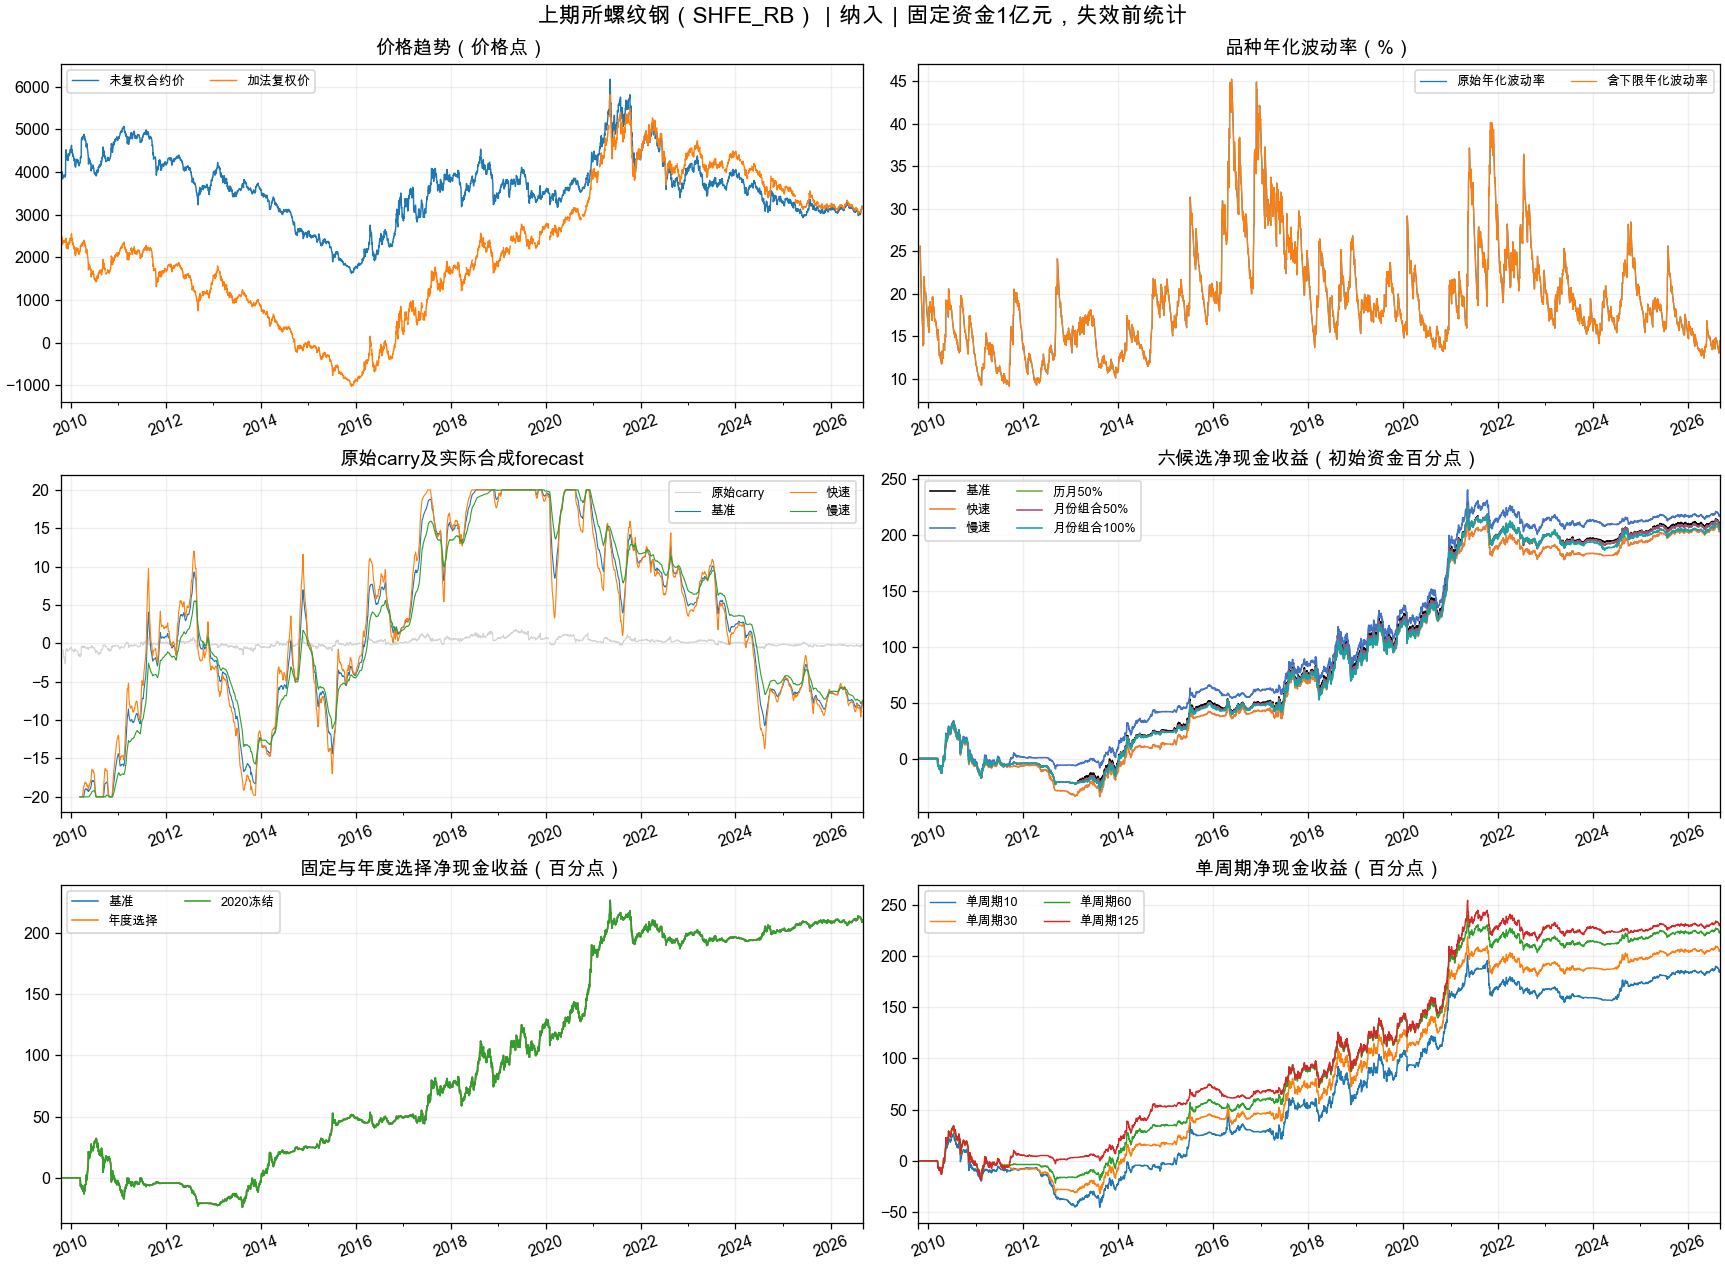

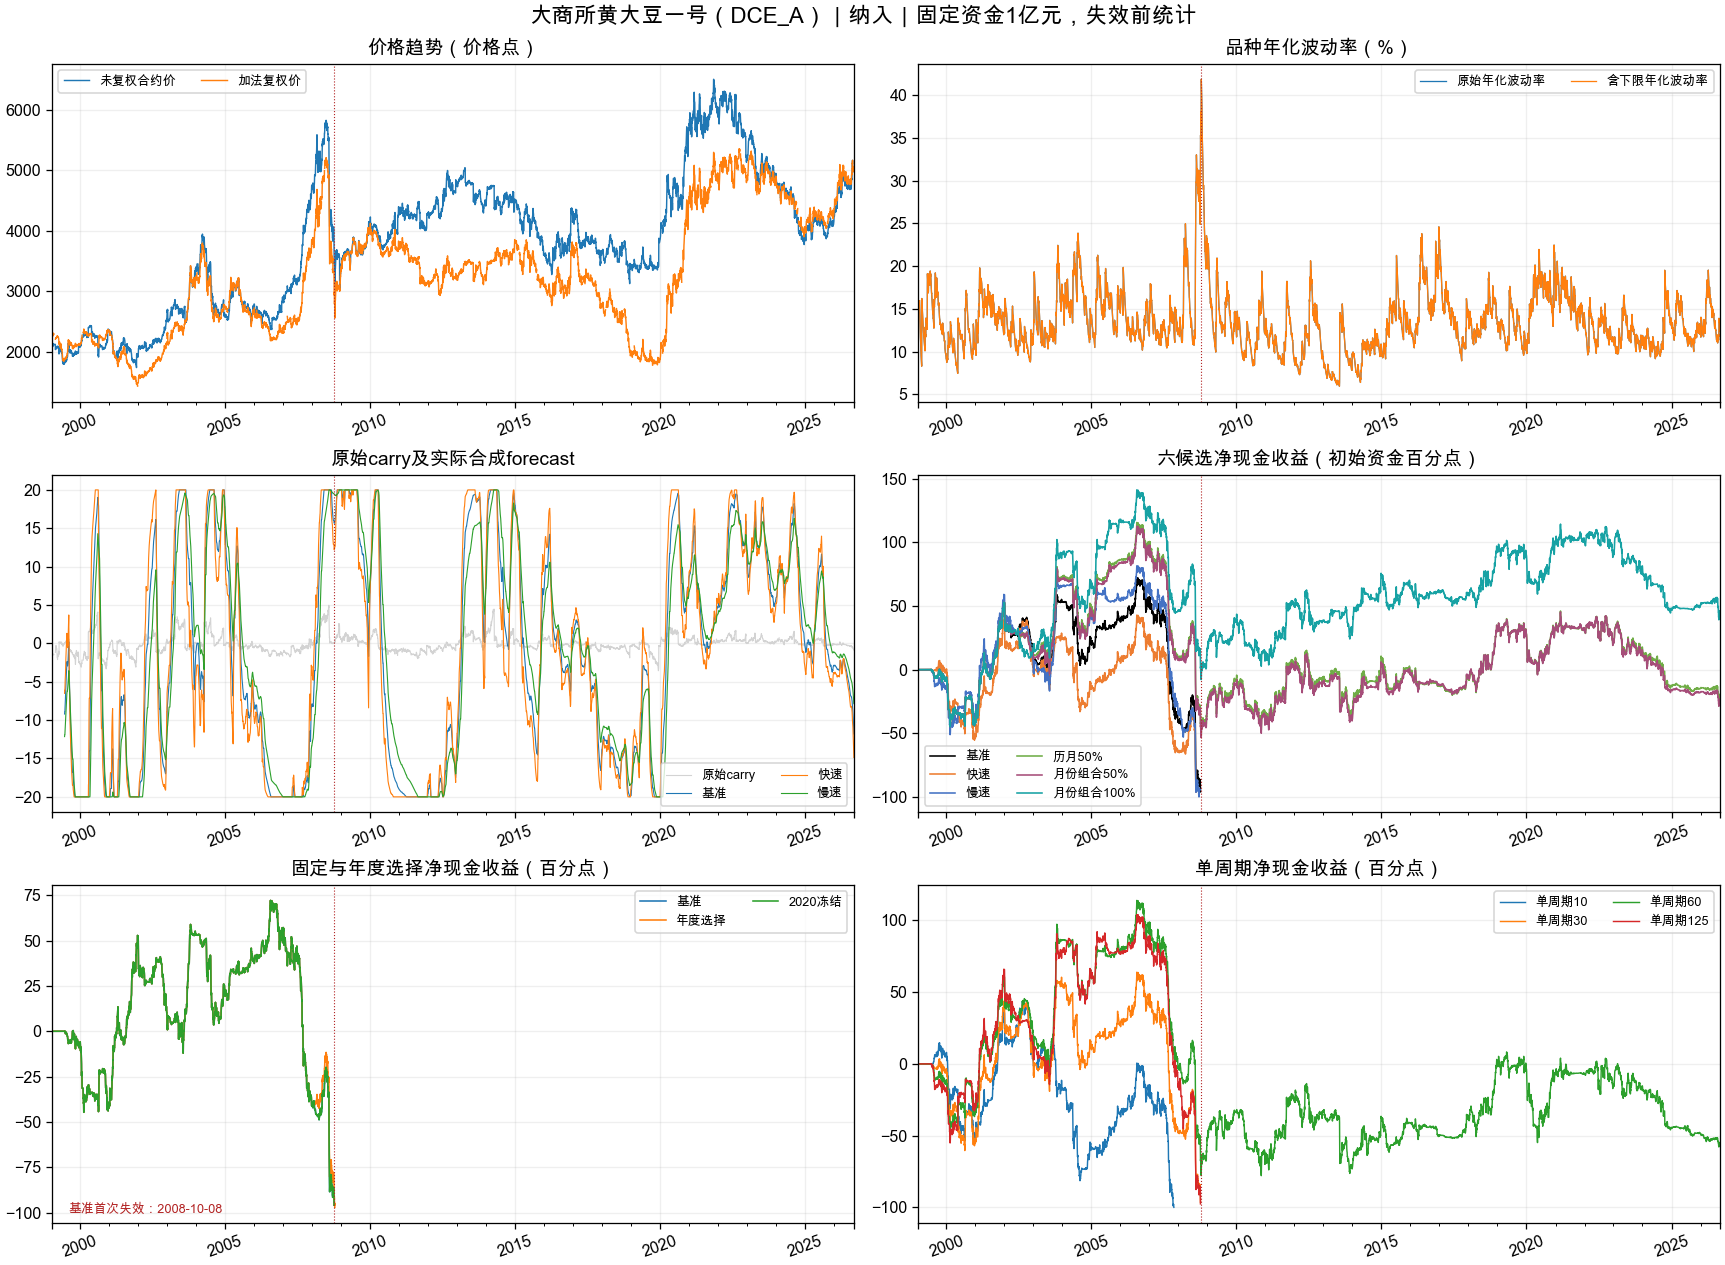

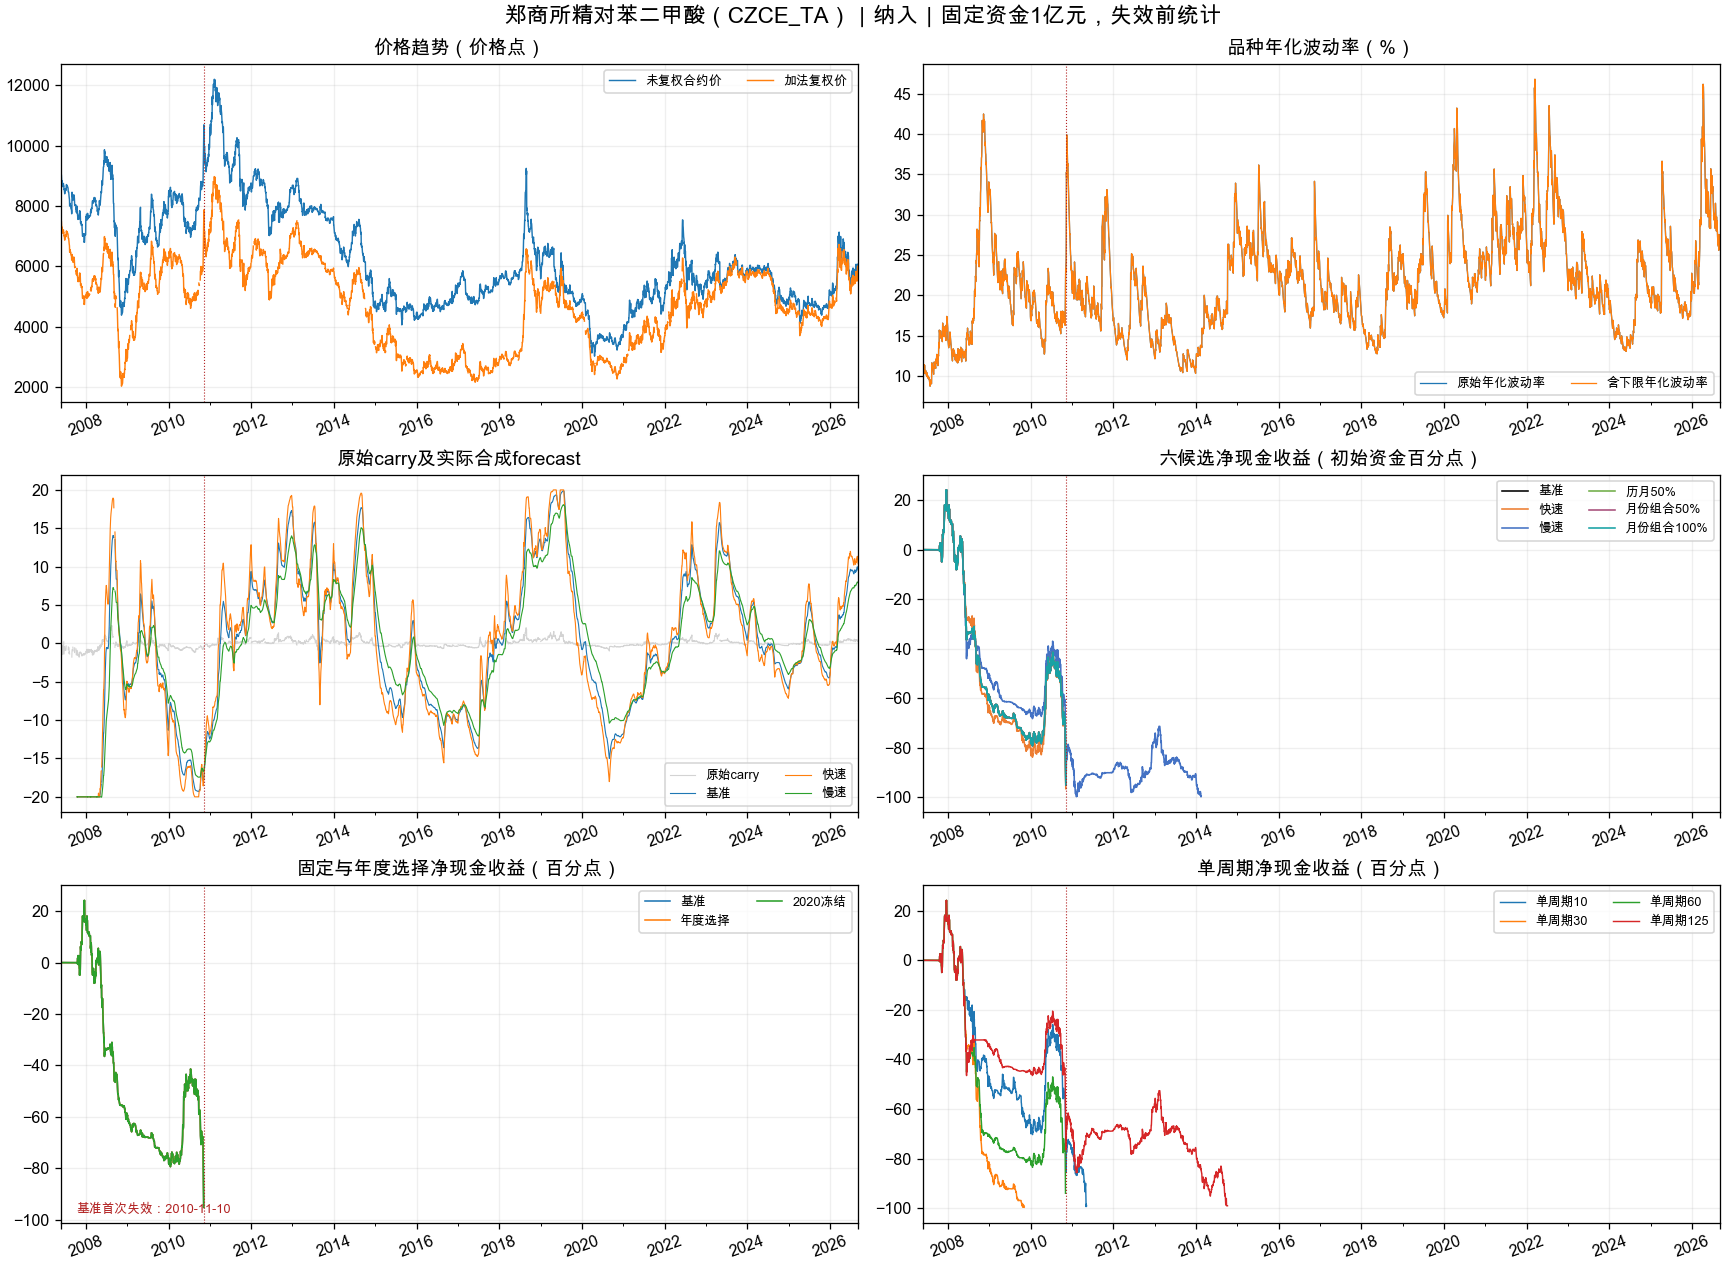

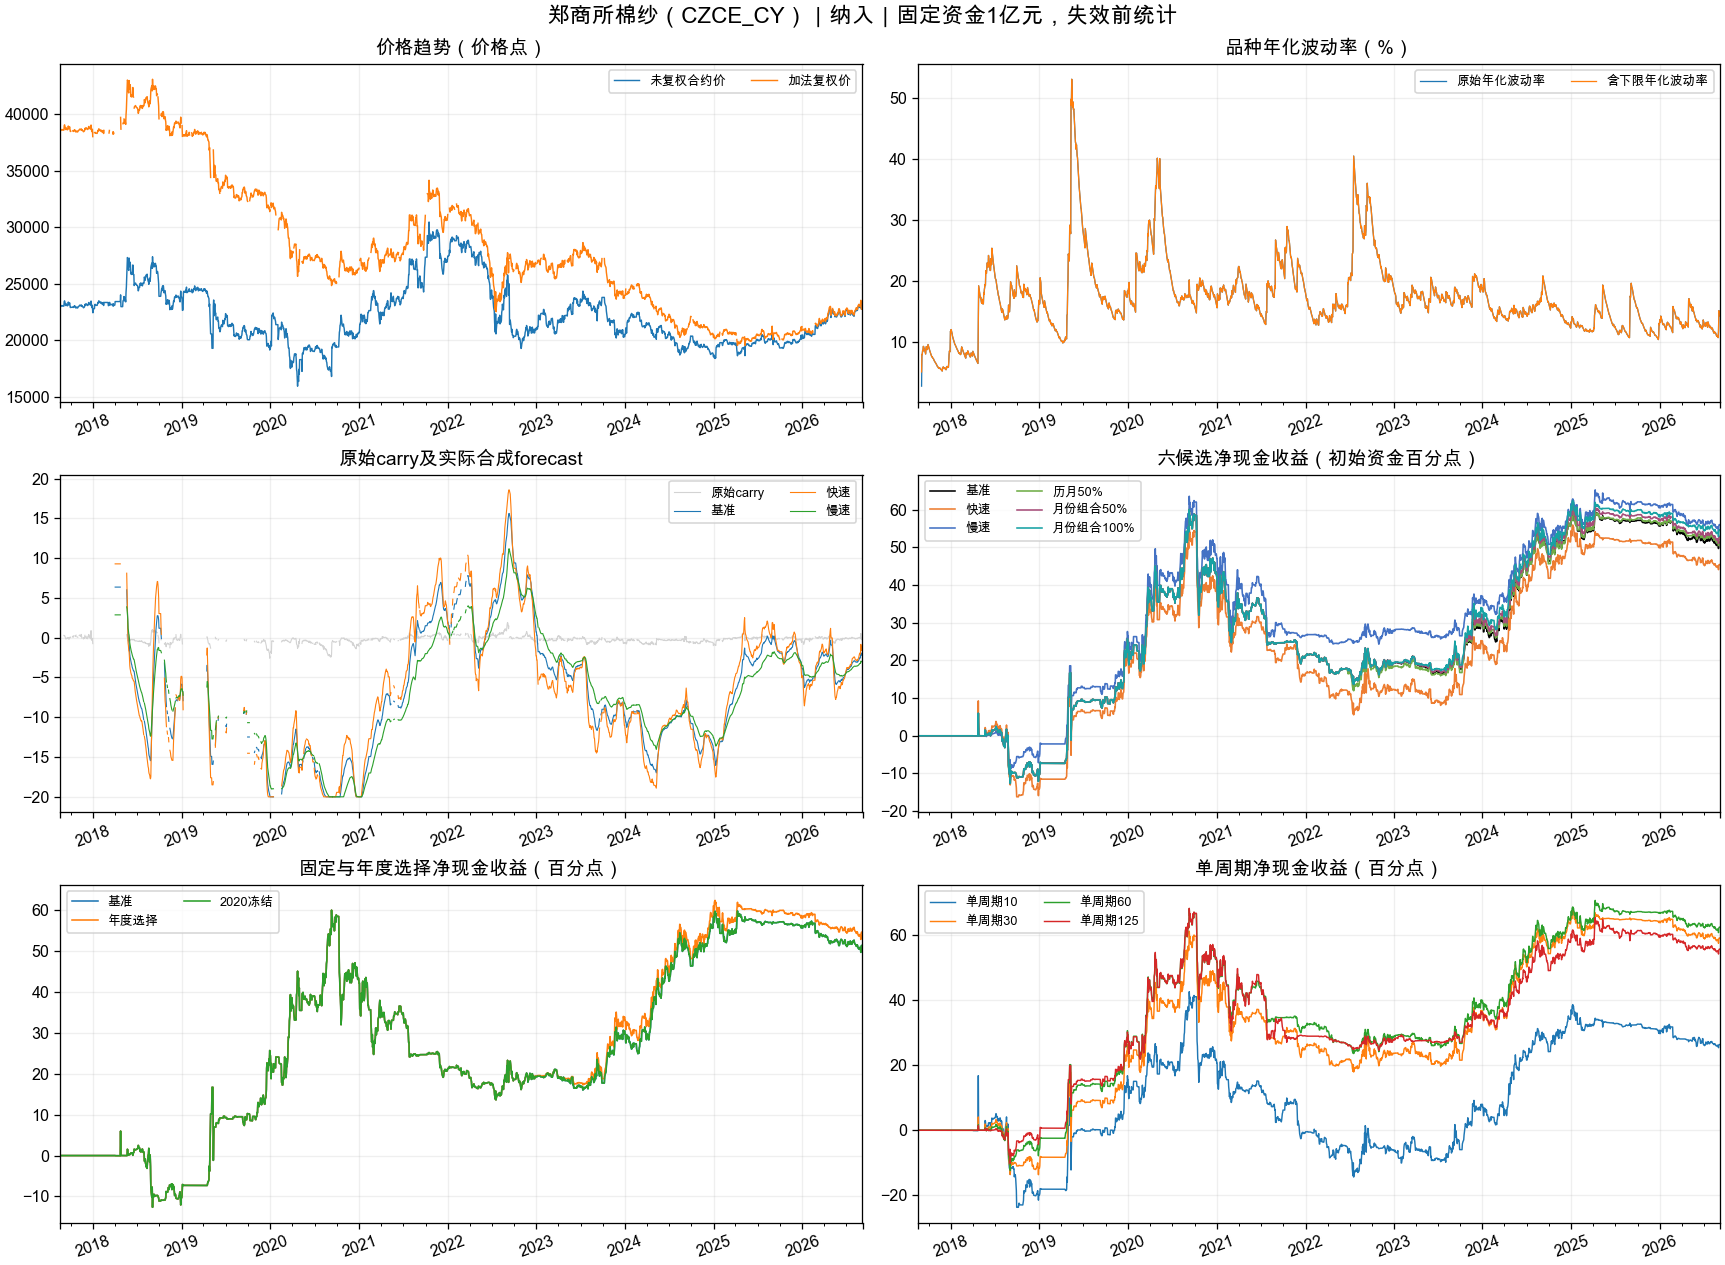

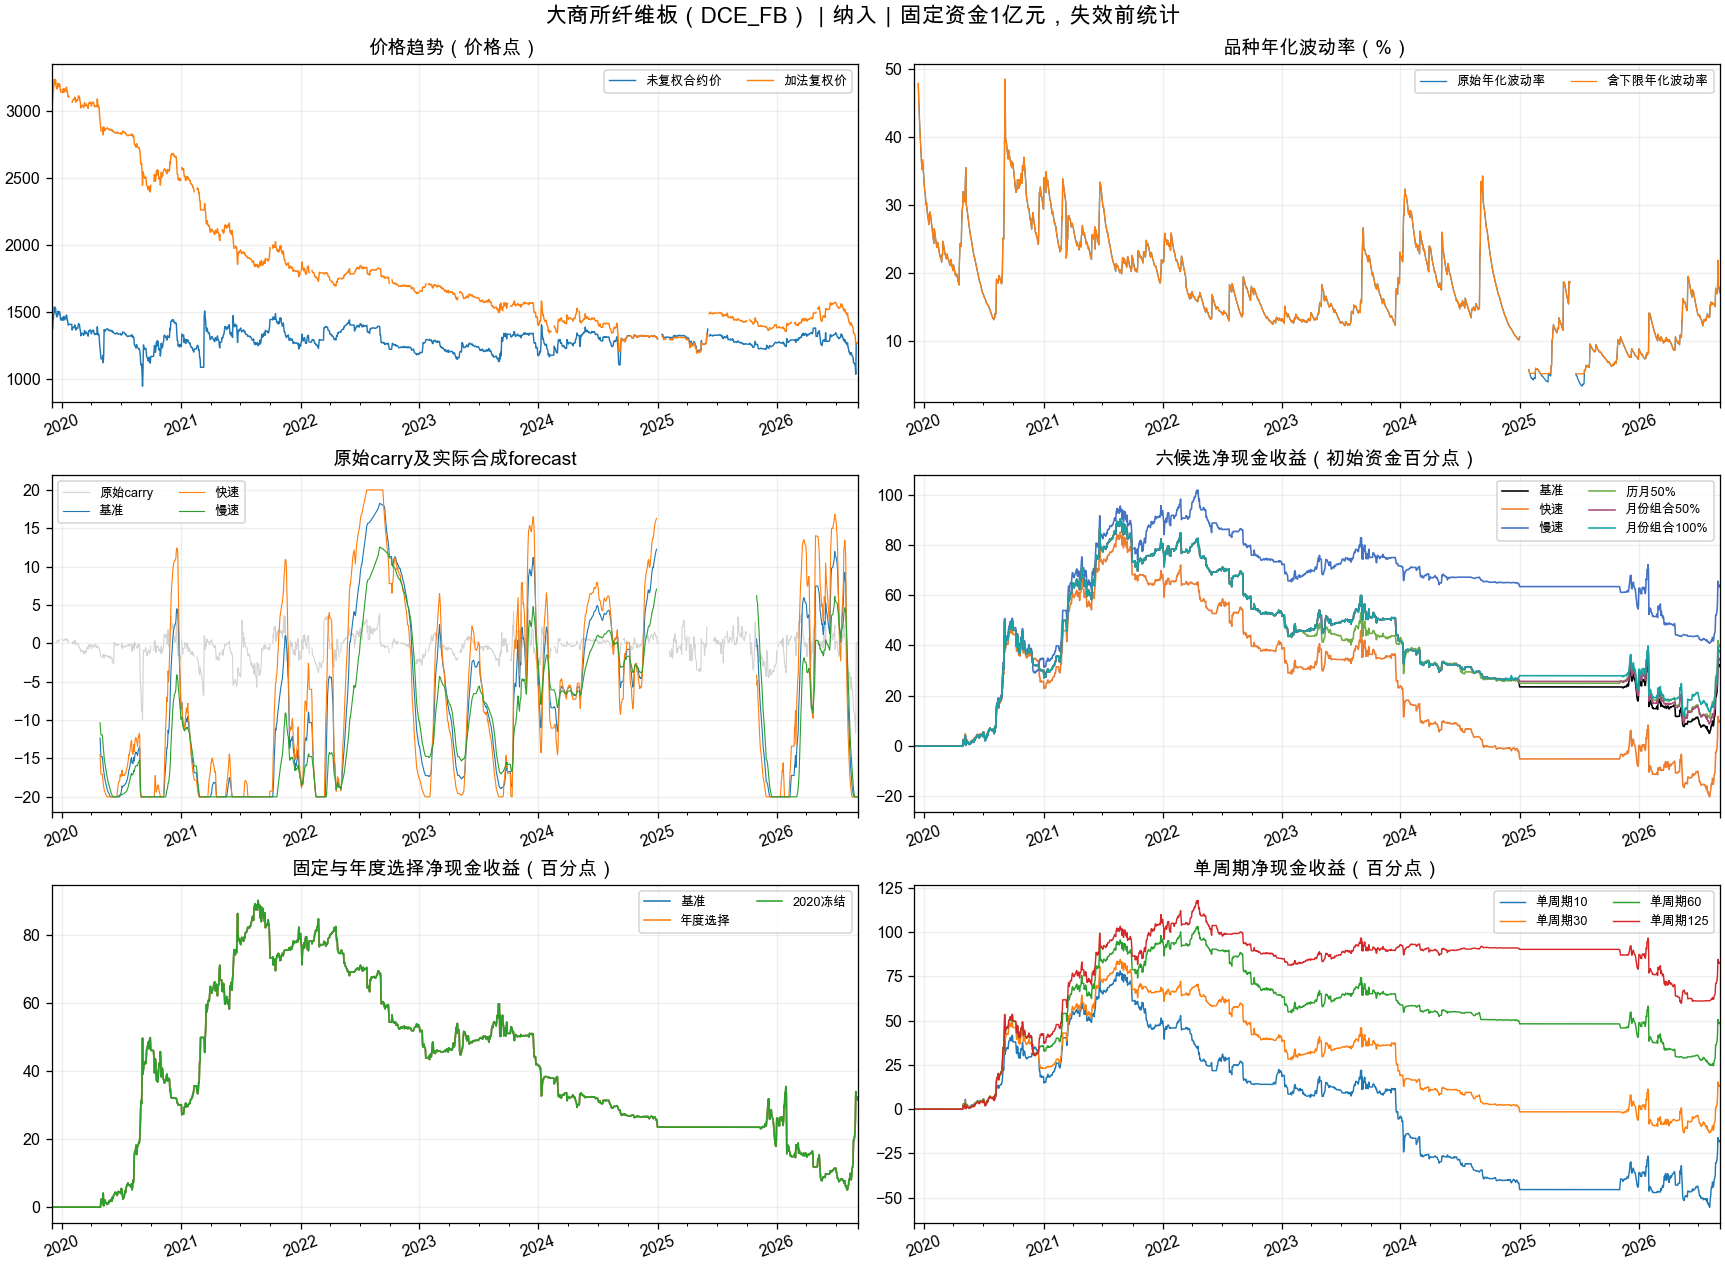

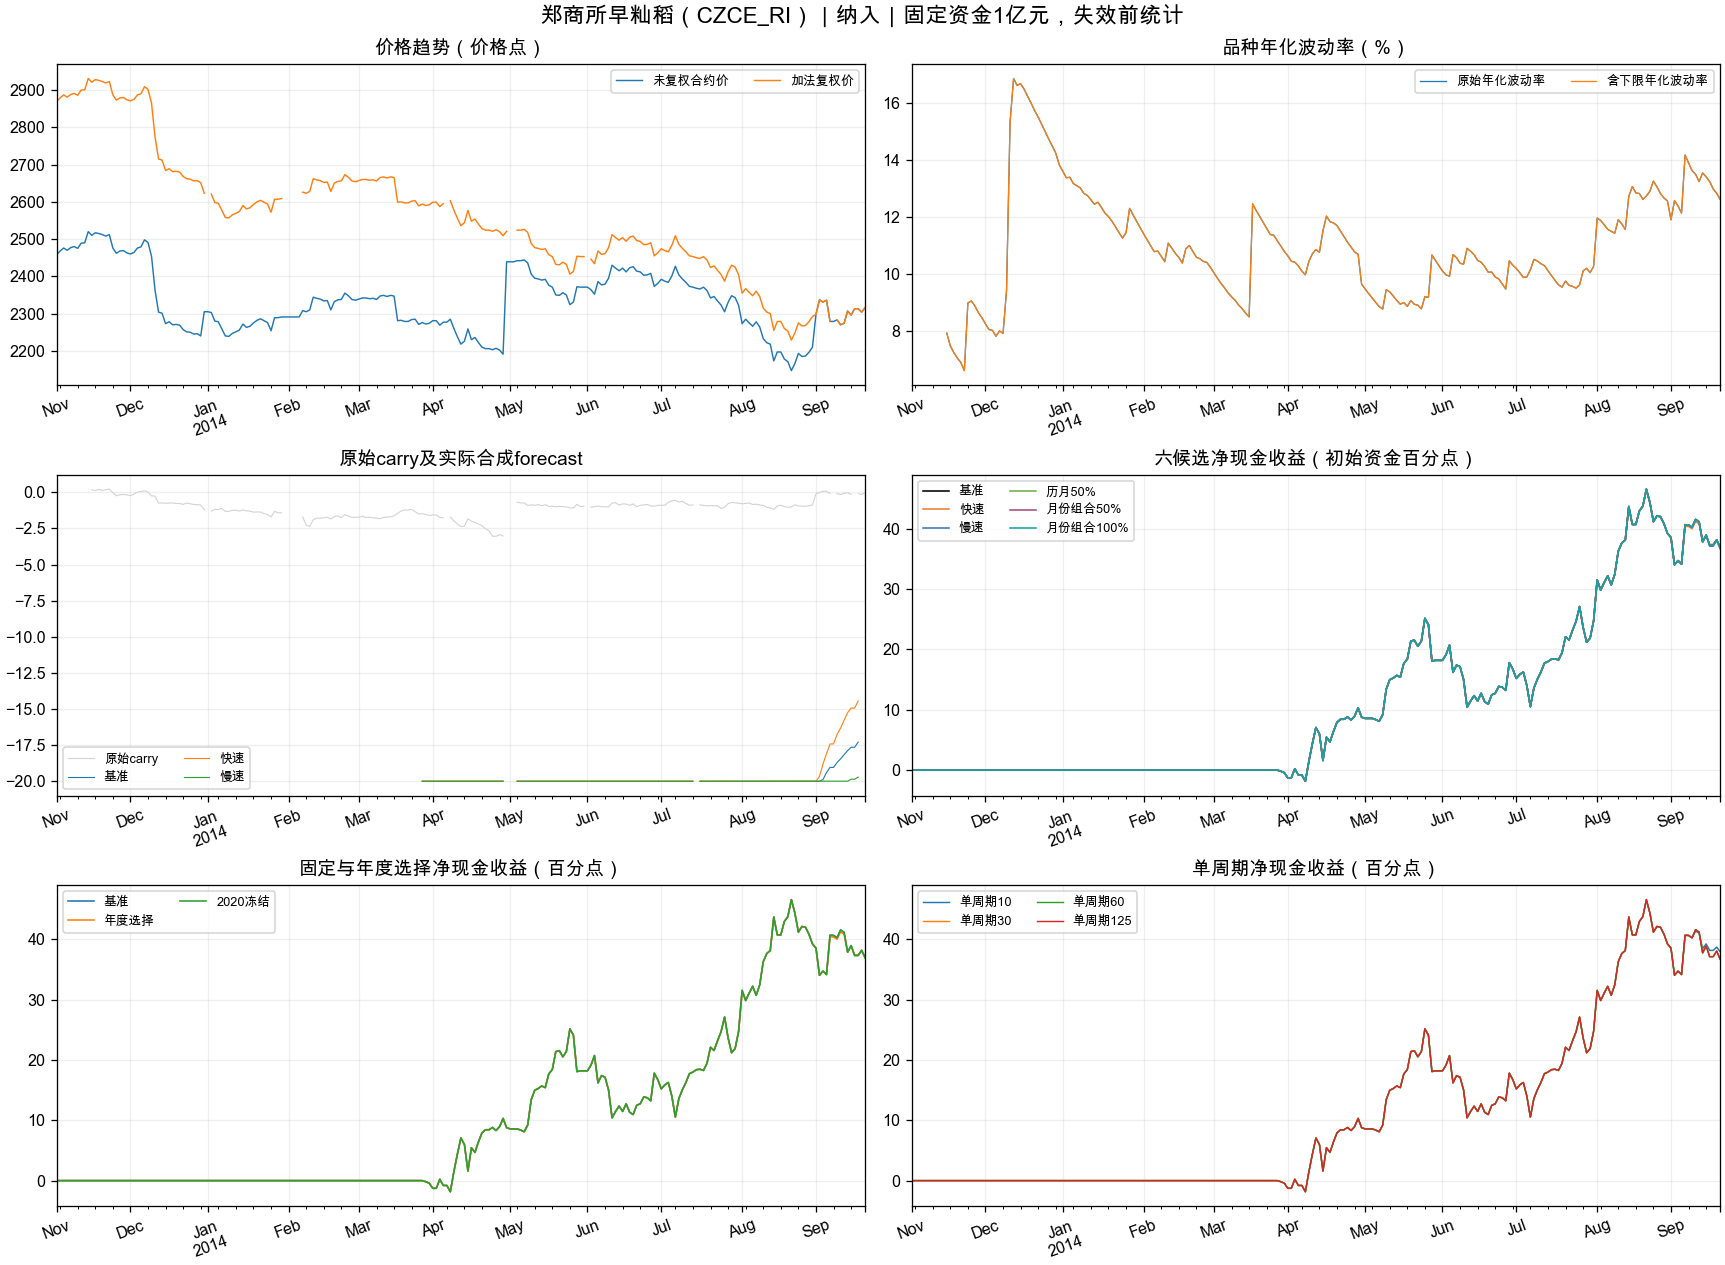

In [23]:
# 95个品种逐一保存六面板；报告显示代表页，目录表提供全部页入口。
from IPython.display import Image as DisplayImage
plt.style.use('default')
plt.rcParams.update({'font.family':'Arial Unicode MS','axes.grid':True,'grid.alpha':.2,'figure.dpi':110})
LABELS = {'baseline':'基准','fast':'快速','slow':'慢速','calendar50':'历月50%','pair50':'月份组合50%',
    'pair100':'月份组合100%','annual':'年度选择','frozen':'2020冻结','amplitude_fast':'快速幅度匹配','amplitude_slow':'慢速幅度匹配',
    'single10':'单周期10','single30':'单周期30','single60':'单周期60','single125':'单周期125'}
COLORS = dict(zip(CANDIDATES,['black','#ed7d31','#4472c4','#70ad47','#a64d79','#17a2a4']))
page_rows = []
for number,code in enumerate(instruments,1):
    fig,axes = plt.subplots(3,2,figsize=(15,11),layout='constrained')
    ax = axes.ravel()
    description = classification.loc[code,'Description']
    status = coverage.loc[code,'decision']
    f = market.get(code,pd.DataFrame())
    if len(f):
        f[['price','adjusted_price']].rename(columns={'price':'未复权合约价','adjusted_price':'加法复权价'}).plot(ax=ax[0],lw=.9)
        f[['raw_vol_pct','used_vol_pct']].rename(columns={'raw_vol_pct':'原始年化波动率','used_vol_pct':'含下限年化波动率'}).plot(ax=ax[1],lw=.8)
        if code in eligible_codes:
            f.raw_carry.plot(ax=ax[2],color='lightgrey',lw=.7,label='原始carry')
            for candidate in ['baseline','fast','slow']:
                shadow_frames[(candidate,code)].forecast.where(eligibility[code]).plot(ax=ax[2],lw=.7,label=LABELS[candidate])
            for candidate in CANDIDATES:
                frame = shadow_frames[(candidate,code)]
                failure = all_receipts.loc[all_receipts.candidate.eq(candidate)&all_receipts.instrument.eq(code),'failure'].iloc[0]
                pct = frame.net_pct.loc[frame.index<failure] if pd.notna(failure) else frame.net_pct
                pct.cumsum().plot(ax=ax[3],lw=1,color=COLORS[candidate],label=LABELS[candidate])
            for candidate in ['baseline','annual','frozen']:
                frame = all_frames[(candidate,code)]
                failure = all_receipts.loc[all_receipts.candidate.eq(candidate)&all_receipts.instrument.eq(code),'failure'].iloc[0]
                pct = frame.net_pct.loc[frame.index<failure] if pd.notna(failure) else frame.net_pct
                pct.cumsum().plot(ax=ax[4],lw=1,label=LABELS[candidate])
            for candidate in ['single10','single30','single60','single125']:
                frame = shadow_frames[(candidate,code)]
                failure = all_receipts.loc[all_receipts.candidate.eq(candidate)&all_receipts.instrument.eq(code),'failure'].iloc[0]
                pct = frame.net_pct.loc[frame.index<failure] if pd.notna(failure) else frame.net_pct
                pct.cumsum().plot(ax=ax[5],lw=.9,label=LABELS[candidate])
        else:
            for a in ax[2:]:
                a.text(.5,.5,status,ha='center',va='center',transform=a.transAxes)
    else:
        for a in ax:
            a.text(.5,.5,status,ha='center',va='center',transform=a.transAxes)
    titles = ['价格趋势（价格点）','品种年化波动率（%）','原始carry及实际合成forecast',
              '六候选净现金收益（初始资金百分点）','固定与年度选择净现金收益（百分点）','单周期净现金收益（百分点）']
    for a,title in zip(ax,titles):
        a.set_title(title)
        if a.get_legend_handles_labels()[0]:
            a.legend(fontsize=8,loc='best',ncol=2)
        if len(f) and f.price.notna().any():
            a.set_xlim(f.price.first_valid_index(),f.price.last_valid_index())
        a.set_xlabel('')
        a.tick_params(axis='x',rotation=20)
    if code in eligible_codes:
        baseline_failure = all_receipts.loc[all_receipts.candidate.eq('baseline')&all_receipts.instrument.eq(code),'failure'].iloc[0]
        if pd.notna(baseline_failure):
            for a in ax:
                a.axvline(baseline_failure,color='firebrick',ls=':',lw=.7)
            ax[4].text(.02,.03,f'基准首次失效：{baseline_failure:%Y-%m-%d}',transform=ax[4].transAxes,color='firebrick',fontsize=8)
    fig.suptitle(f'{description}（{code}）｜{status}｜固定资金1亿元，失效前统计',fontsize=14)
    path = RUN_ROOT/'figures'/f'{code}.png'
    fig.savefig(path,dpi=115)
    plt.close(fig)
    page_rows.append(dict(instrument=code,description=description,decision=status,path=str(path)))
    if number%15==0:
        print('逐品种图页',number,'/',len(instruments),flush=True)
pages = pd.DataFrame(page_rows)
pages.to_csv(RUN_ROOT/'instrument_figure_index.csv',index=False)
with pd.option_context('display.max_rows',100,'display.max_colwidth',160):
    display(pages[['instrument','description','decision','path']])
for code in ['SHFE_RB','DCE_A','CZCE_TA','CZCE_CY','DCE_FB','CZCE_RI']:
    display(DisplayImage(filename=str(RUN_ROOT/'figures'/f'{code}.png')))


In [32]:
from sysobjects.carry_data import rawCarryData
season_evidence = pd.DataFrame(seasonal_rows)
latest_market = pd.read_parquet(SHARED/'market.parquet')
pd.testing.assert_frame_equal(market_frame.drop(columns='roll_differential'),latest_market.drop(columns='roll_differential'))
market_frame = latest_market
for code in market:
    market[code]['roll_differential'] = latest_market.xs(code,level='instrument').roll_differential
prefix_checks, roll_checks = [], []
assert pd.DataFrame(seasonal_status).training_end.lt(pd.DataFrame(seasonal_status).decision_year).all()
for code in eligible_codes:
    f = market[code]
    native_gap = rawCarryData(f[['PRICE','CARRY','PRICE_CONTRACT','CARRY_CONTRACT']]).roll_differentials()
    paired_gap = pd.concat([f.roll_differential.rename('shared'),native_gap.rename('native')],axis=1).dropna()
    if len(paired_gap):
        np.testing.assert_allclose(paired_gap.shared,paired_gap.native,atol=1e-10)
    roll_checks.append(dict(instrument=code,shared_non_null=int(f.roll_differential.notna().sum()),
        native_non_null=int(native_gap.notna().sum()),observed=int(f.observed.sum()),
        common_rows=len(paired_gap),max_abs_difference=(paired_gap.shared-paired_gap.native).abs().max()))
roll_comparison = pd.DataFrame(roll_checks)
assert roll_comparison.common_rows.eq(roll_comparison.native_non_null).all()
roll_comparison.to_csv(RUN_ROOT/'contract_roll_gap_check.csv',index=False)
for code in ['SHFE_RB','DCE_A','CZCE_CY']:
    f = market[code]
    keys = pd.concat(raw_diagnostics).query('instrument == @code')
    for cutoff in [pd.Timestamp('2020-12-31'),pd.Timestamp('2023-06-30')]:
        history = f.loc[:cutoff]
        correction = pd.DataFrame(0.,index=history.index,columns=['calendar','pair'])
        for year in history.index.year.unique():
            dates = history.index[history.index.year==year]
            for kind,key in [('calendar','month_key'),('pair','pair_key')]:
                table = season_evidence.loc[season_evidence.instrument.eq(code)&season_evidence.decision_year.eq(year)&season_evidence.kind.eq(kind)]
                template = table.set_index('key').seasonal
                correction.loc[dates,kind] = keys.loc[dates,key].map(template).fillna(0.)
        ratio = history.price.abs()/(history.used_vol_points*np.sqrt(ANNUAL_DAYS))
        raw_inputs = {'baseline':history.raw_carry,'fast':history.raw_carry,'slow':history.raw_carry,
            'calendar50':history.raw_carry-.5*correction.calendar*ratio,
            'pair50':history.raw_carry-.5*correction.pair*ratio,
            'pair100':history.raw_carry-correction.pair*ratio}
        for candidate in CANDIDATES:
            for slot,com in zip(SLOTS,PERIODS[candidate]):
                rebuilt = pd.Series(np.nan,index=history.index)
                for window in history.window.dropna().unique():
                    dates = history.index[history.window.eq(window)]
                    rebuilt.loc[dates] = carry(raw_inputs[candidate].loc[dates],smooth_days=com)
                np.testing.assert_allclose(rebuilt,candidate_rules['annual'][code].loc[history.index,candidate+'__'+slot],equal_nan=True,atol=1e-10)
                prefix_checks.append(dict(instrument=code,cutoff=cutoff,candidate=candidate,slot=slot,passed=True))
for code in eligible_codes:
    dates = implemented_rules['frozen'][code].index
    old = dates[dates.year<2021]
    np.testing.assert_allclose(implemented_rules['frozen'][code].loc[old],
        raw_rule_frames[code].reindex(old)[SLOTS],equal_nan=True,atol=1e-10)
for (candidate,code),frame in all_frames.items():
    np.testing.assert_allclose(frame.net_pct.fillna(0),frame.gross_pct.fillna(0)+frame.cost_pct.fillna(0),atol=1e-8)
    np.testing.assert_allclose(frame.net_cnh.fillna(0),frame.net_pct.fillna(0)*CAPITAL/100,atol=.01)
    assert frame.index.max()<=CUTOFF
    np.testing.assert_allclose(frame.held,frame.order.shift(1).fillna(0))
    assert frame.order.mod(1).eq(0).all()
    assert frame.forecast.dropna().abs().le(20+1e-8).all()
assert len(all_frames)==1260 and len(pages)==95 and len(eligible_codes)==90
pd.DataFrame(prefix_checks).to_csv(RUN_ROOT/'historical_prefix_checks.csv',index=False)
validation = pd.DataFrame([
    dict(check='90个baseline与主报告逐值相等',value=len(common_rows),passed=True),
    dict(check='季节及平滑历史截断',value=len(prefix_checks),passed=True),
    dict(check='原生延迟整手资金与费用恒等式',value=len(all_frames),passed=True),
    dict(check='完整品种及图表覆盖',value=len(pages),passed=True),
    dict(check='合约期限差原生对照',value=int(roll_comparison.common_rows.sum()),passed=True),
    dict(check='日期截止',value=AS_OF,passed=True),
    dict(check='内存实际市场输入SHA256',value=hashlib.sha256(pd.util.hash_pandas_object(market_frame,index=True).values.tobytes()).hexdigest(),passed=True),
    dict(check='资格掩码SHA256',value=hashlib.sha256(pd.util.hash_pandas_object(eligibility,index=True).values.tobytes()).hexdigest(),passed=True)])
validation.to_csv(RUN_ROOT/'validation.csv',index=False)
display(validation)


,check,value,passed
0,90个baseline与主报告逐值相等,737190,True
1,季节及平滑历史截断,144,True
2,原生延迟整手资金与费用恒等式,1260,True
3,完整品种及图表覆盖,95,True
4,合约期限差原生对照,205265,True
5,日期截止,2026-09-07,True
6,内存实际市场输入SHA256,e60f9696e79d2f7f01091b1ea43097e4f81d1f603f1142...,True
7,资格掩码SHA256,e44147a7a4d756aff29e6c5eb7ebe3cd40bf69c2e24600...,True


,candidate,instruments,mean_sharpe_delta,median_sharpe_delta,positive_share
0,fast,75,0.020,0.002,0.507
1,slow,74,-0.007,0.000,0.500
2,calendar50,75,0.008,0.000,0.467
3,pair50,75,0.008,0.000,0.480
4,pair100,75,0.018,0.000,0.440
5,annual,75,0.018,0.000,0.160
6,frozen,75,0.018,0.000,0.120
7,amplitude_fast,75,0.017,-0.001,0.480
8,amplitude_slow,74,-0.005,-0.002,0.473


,broad,candidate,markets,reason,train_sharpe,validate_sharpe
1560,股指,baseline,1,10年历史或合格经济市场不足3个,NaN,NaN
1566,利率,baseline,0,10年历史或合格经济市场不足3个,NaN,NaN
1577,农产品,pair100,9,训练及验证门槛通过,0.940259,0.411561
1578,化工,baseline,5,训练优势不足0.05,1.172160,0.086665
1584,黑色,baseline,4,验证未达到正净收益及Sharpe优势0.10,1.364098,1.761152
1590,林木造纸,baseline,0,10年历史或合格经济市场不足3个,NaN,NaN
1596,能源,baseline,1,10年历史或合格经济市场不足3个,NaN,NaN
1602,有色,baseline,4,验证未达到正净收益及Sharpe优势0.10,0.845286,0.989081
1608,贵金属,baseline,2,10年历史或合格经济市场不足3个,NaN,NaN
1614,航运,baseline,0,10年历史或合格经济市场不足3个,NaN,NaN


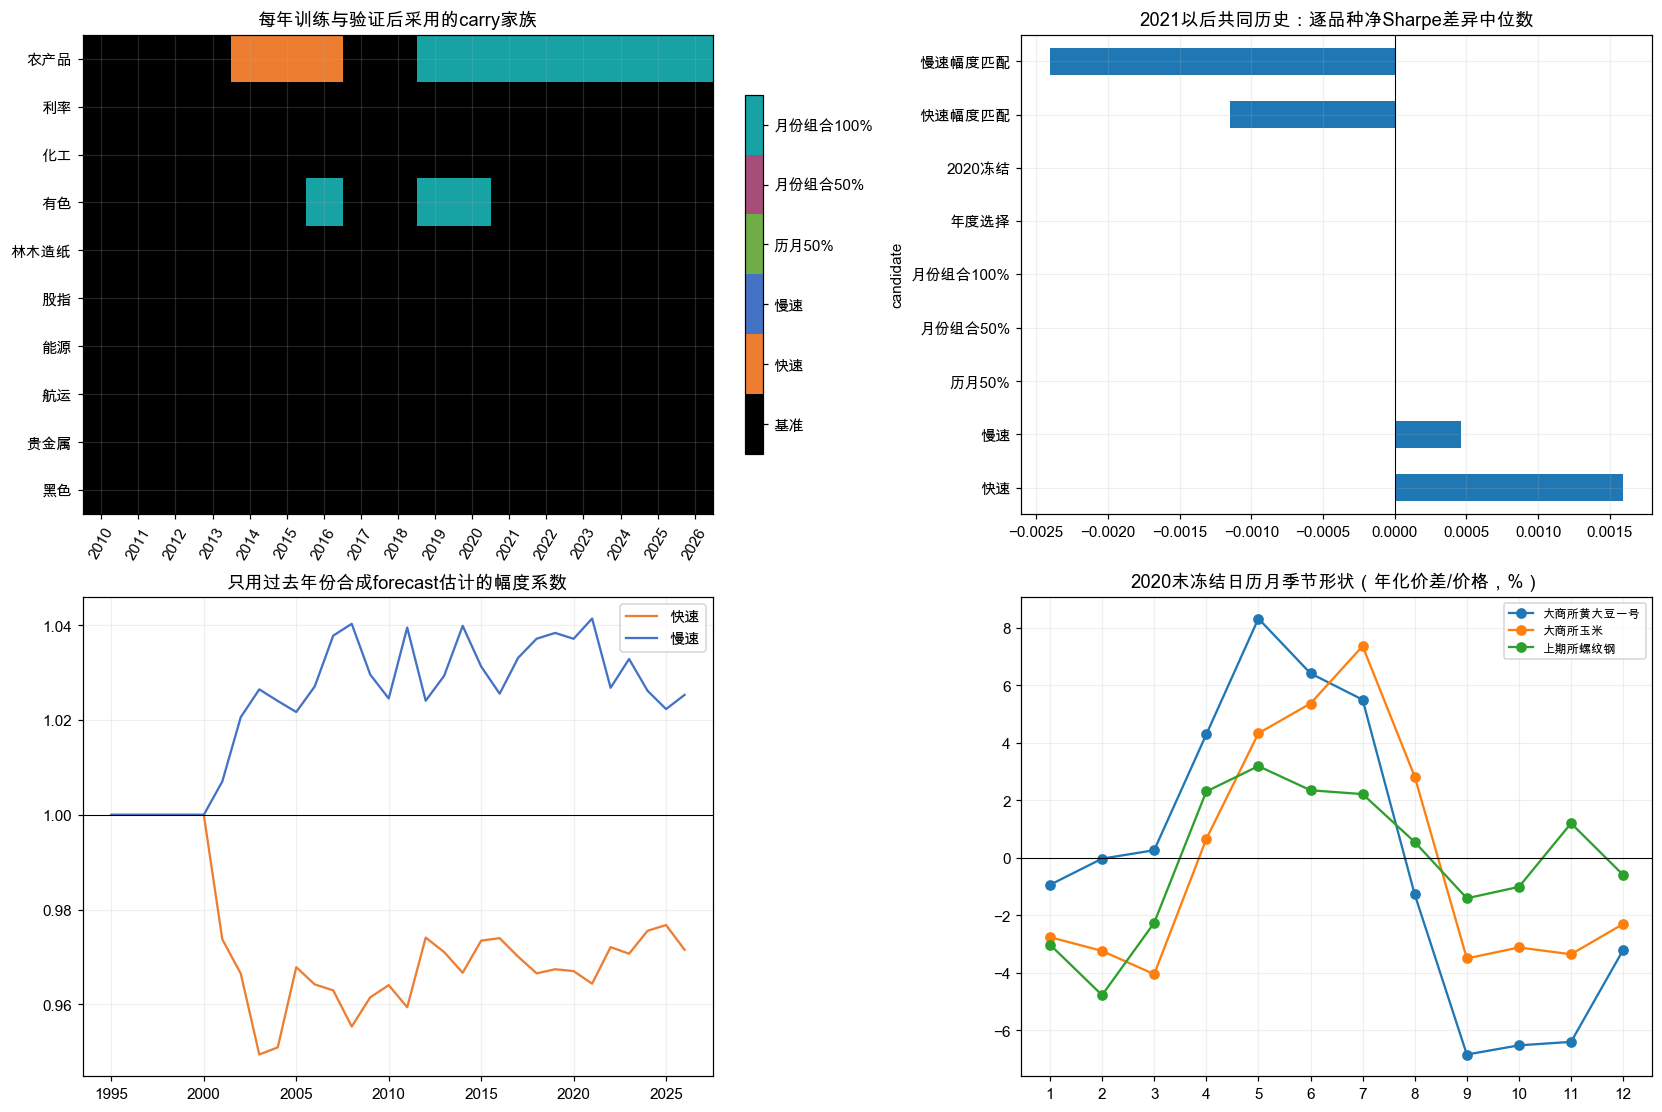

In [30]:
# 先看共同历史中的配对差异，再看不同日期训练后选择的实际路径。
joint = metrics.loc[metrics.period.eq('14候选共同2021以后')]
wide = joint.pivot(index='instrument',columns='candidate',values='net_sharpe')
pair_rows = []
for candidate in CANDIDATES[1:]+['annual','frozen','amplitude_fast','amplitude_slow']:
    delta = (wide[candidate]-wide.baseline).dropna()
    pair_rows.append(dict(candidate=candidate,instruments=len(delta),mean_sharpe_delta=delta.mean(),
        median_sharpe_delta=delta.median(),positive_share=delta.gt(0).mean()))
paired_diagnostics = pd.DataFrame(pair_rows)
paired_diagnostics.to_csv(RUN_ROOT/'paired_instrument_diagnostics.csv',index=False)
display(paired_diagnostics.round(3))
display(frozen_selection.loc[frozen_selection.selected,['broad','candidate','markets','reason','train_sharpe','validate_sharpe']])
fig,axes = plt.subplots(2,2,figsize=(15,10),layout='constrained')
selected = selection.loc[selection.selected&selection.decision_year.ge(2010)]
adoption = selected.pivot(index='broad',columns='decision_year',values='candidate')
matrix = adoption.apply(lambda column:column.map({c:i for i,c in enumerate(CANDIDATES)}))
from matplotlib.colors import ListedColormap
color = ListedColormap([COLORS[c] for c in CANDIDATES])
im = axes[0,0].imshow(matrix,aspect='auto',vmin=-.5,vmax=5.5,cmap=color)
axes[0,0].set_xticks(range(len(matrix.columns)),matrix.columns,rotation=60)
axes[0,0].set_yticks(range(len(matrix)),matrix.index)
bar = fig.colorbar(im,ax=axes[0,0],ticks=range(6),shrink=.75)
bar.ax.set_yticklabels([LABELS[c] for c in CANDIDATES])
axes[0,0].set_title('每年训练与验证后采用的carry家族')
paired_diagnostics.set_index('candidate').median_sharpe_delta.rename(index=LABELS).plot.barh(ax=axes[0,1])
axes[0,1].axvline(0,color='black',lw=.7)
axes[0,1].set_title('2021以后共同历史：逐品种净Sharpe差异中位数')
for candidate in ['fast','slow']:
    part = amplitude.loc[amplitude.candidate.eq(candidate)].set_index('decision_year')
    axes[1,0].plot(part.index,part.ratio,label=LABELS[candidate],color=COLORS[candidate])
axes[1,0].axhline(1,color='black',lw=.7)
axes[1,0].legend()
axes[1,0].set_title('只用过去年份合成forecast估计的幅度系数')
shape = season_evidence.loc[season_evidence.decision_year.eq(2021)&season_evidence.kind.eq('calendar')&
    season_evidence.instrument.isin(['DCE_A','DCE_C','CZCE_CY','SHFE_RB'])].copy()
shape['month'] = shape.key.astype(int)
for code,part in shape.groupby('instrument'):
    part = part.sort_values('month')
    axes[1,1].plot(part.month,part.seasonal*100,marker='o',label=classification.loc[code,'Description'])
axes[1,1].set_xticks(range(1,13))
axes[1,1].axhline(0,color='black',lw=.7)
axes[1,1].legend(fontsize=8)
axes[1,1].set_title('2020末冻结日历月季节形状（年化价差/价格，%）')
fig.savefig(RUN_ROOT/'figures/diagnostic_summary.png',dpi=130)
plt.show()


In [31]:
# 根据本次实际结果写出诊断结论，表中成本为负的收益贡献。
paired = paired_diagnostics.set_index('candidate')
post2021_joint = metrics.loc[metrics.period.eq('14候选共同2021以后')]
single_joint = metrics.loc[metrics.period.eq('14候选共同历史')&
    metrics.candidate.isin(['single10','single30','single60','single125'])].groupby('candidate').net_sharpe.median()
gross_losers = loss_diagnoses.reason.str.startswith('毛收益为负').sum()
cost_losers = len(loss_diagnoses)-gross_losers
fixed_choices = frozen_selection.loc[frozen_selection.selected & frozen_selection.candidate.ne('baseline')]
choice_text = '、'.join(f'{row.broad}采用{LABELS[row.candidate]}（{row.markets}个合格经济市场）' for row in fixed_choices.itertuples())
diagnostic_conclusion = f"""## 本轮诊断得到什么

90个可计算品种中，纯carry基准在各自失效前完整历史里有{len(loss_diagnoses)}个净现金收益为负，其中{gross_losers}个毛收益已为负，{cost_losers}个因费用超过正毛收益。亏损明细逐一列出最差年度、PRICE/CARRY交割月份和费用。费用只是其中一个可量化来源。

2021年以来共同历史中，快速家族相对基准的净Sharpe变化中位数为{paired.loc['fast','median_sharpe_delta']:+.3f}，慢速为{paired.loc['slow','median_sharpe_delta']:+.3f}；月份组合100%调整为{paired.loc['pair100','median_sharpe_delta']:+.3f}，改善品种占{paired.loc['pair100','positive_share']:.1%}。统一改变平滑周期或季节形状的跨品种效果有限。公平共同历史中，单周期10和125的净Sharpe中位数分别为{single_joint['single10']:.3f}、{single_joint['single125']:.3f}，慢速信号的成本、响应速度和收益需共同看待。

幅度匹配后，快速家族的净Sharpe差异中位数为{paired.loc['amplitude_fast','median_sharpe_delta']:+.3f}，慢速为{paired.loc['amplitude_slow','median_sharpe_delta']:+.3f}。系数只使用过去完整年份的合成forecast，实际匹配仍受逐rule cap、最终cap和品种分布影响；信号表保留了匹配残差。

2020年末冻结选择为：{choice_text or '全部保留基准'}。其余类别保留基准，原因包括合格经济市场不足、训练优势不足或验证未通过。季节模型对支持不足的月份组合使用0修正，并保持训练历史的年度等权长期均值。已实施路径按这些门槛执行调整。

黄大豆一号（DCE_A）的固定观察账户在2008年失效，2021后的正常观察账户评分不再包含这段失效后路径。组合使用自身资金和风险预算独立计算交易。全部首次失效日与原始损失已另存，正常排名截止失效前。最终组合的采用判断继续结合下方配对结果与按年重抽样区间。"""
display(Markdown(diagnostic_conclusion))
_ = (RUN_ROOT/'diagnostic_conclusion.md').write_text(diagnostic_conclusion,encoding='utf-8')


## 本轮诊断得到什么

90个可计算品种中，纯carry基准在各自失效前完整历史里有31个净现金收益为负，其中31个毛收益已为负，0个因费用超过正毛收益。亏损明细逐一列出最差年度、PRICE/CARRY交割月份和费用。费用只是其中一个可量化来源。

2021年以来共同历史中，快速家族相对基准的净Sharpe变化中位数为+0.002，慢速为+0.000；月份组合100%调整为+0.000，改善品种占44.0%。统一改变平滑周期或季节形状的跨品种效果有限。公平共同历史中，单周期10和125的净Sharpe中位数分别为0.287、0.198，慢速信号的成本、响应速度和收益需共同看待。

幅度匹配后，快速家族的净Sharpe差异中位数为-0.001，慢速为-0.002。系数只使用过去完整年份的合成forecast，实际匹配仍受逐rule cap、最终cap和品种分布影响；信号表保留了匹配残差。

2020年末冻结选择为：农产品采用月份组合100%（9个合格经济市场）。其余类别保留基准，原因包括合格经济市场不足、训练优势不足或验证未通过。季节模型对支持不足的月份组合使用0修正，并保持训练历史的年度等权长期均值。已实施路径按这些门槛执行调整。

黄大豆一号（DCE_A）的固定观察账户在2008年失效，2021后的正常观察账户评分不再包含这段失效后路径。组合使用自身资金和风险预算独立计算交易。全部首次失效日与原始损失已另存，正常排名截止失效前。最终组合的采用判断继续结合下方配对结果与按年重抽样区间。

## 组合层的最终复核

下一张表读取同批审核数据的适应性研究结果。最终八组组合统一处理类别 carry 比例与动态暂停，并保留同一份原生费用、风险预算和资金路径。固定与年度选择的组合结论结合共同期间的配对差异、按年重抽样区间，以及换手和实际风险暴露判断。

In [37]:
PORTFOLIO_ROOT = AUDIT_ROOT/'adaptive_research'
portfolio_statistics = pd.read_csv(PORTFOLIO_ROOT/'statistics.csv')
portfolio_pairs = pd.read_csv(PORTFOLIO_ROOT/'paired_comparisons.csv')
bootstrap_path = PORTFOLIO_ROOT/'paired_year_bootstrap.csv'
portfolio_bootstrap = pd.read_csv(bootstrap_path) if bootstrap_path.exists() else pd.DataFrame()
improved_policies = ['improved_annual_mixed40','improved_frozen_mixed40',
    'improved_annual_fine','improved_frozen_fine']
assert set(improved_policies).issubset(set(portfolio_statistics.policy))
comparison_policies = improved_policies+['mixed40','fine_annual']
matches = (portfolio_statistics.policy.isin(improved_policies)
    | (portfolio_statistics.policy.eq('mixed40')&portfolio_statistics.pause.eq(False))
    | (portfolio_statistics.policy.eq('fine_annual')&portfolio_statistics.pause.eq(True)))
portfolio_results = portfolio_statistics.loc[matches&portfolio_statistics.period.isin(['共同历史','2021年以来'])]
display(portfolio_results[['policy','pause','cap','period','cagr','sharpe','max_dd','vol','cost','turnover']].round(4))
carry_pairs = portfolio_pairs.loc[portfolio_pairs.variant.str.contains('improved_',regex=False)].copy()
display(carry_pairs.loc[carry_pairs.period.isin(['共同历史','2021年以来'])].round(4))
if len(portfolio_bootstrap):
    carry_bootstrap = portfolio_bootstrap.loc[portfolio_bootstrap.variant.str.contains('improved_',regex=False)]
    display(carry_bootstrap)
    print('按年重抽样表给出CAGR增量的95%区间，单位为百分点。')
else:
    print('按年重抽样仍在生成，完成后重新运行本cell。')
portfolio_results.to_csv(RUN_ROOT/'final_portfolio_comparison.csv',index=False)
print('CAGR、最大回撤、波动率和成本的单位为%；相应配对变化以百分点计，Sharpe变化保持原单位。')


,policy,pause,cap,period,cagr,sharpe,max_dd,vol,cost,turnover
81,mixed40,False,unlimited,共同历史,19.0093,1.6020,19.6177,11.2623,0.5333,13.1132
82,mixed40,False,unlimited,2021年以来,6.2336,0.7585,13.1598,8.4433,0.2080,10.7470
91,mixed40,False,cap20,共同历史,10.9903,1.3502,13.1558,7.9586,0.2953,8.8070
92,mixed40,False,cap20,2021年以来,6.2287,0.7579,13.1558,8.4441,0.2077,10.7264
301,fine_annual,True,unlimited,共同历史,19.2146,1.6184,19.6177,11.2540,0.5225,12.9853
302,fine_annual,True,unlimited,2021年以来,6.7837,0.8140,13.9855,8.5085,0.2060,10.4451
311,fine_annual,True,cap20,共同历史,11.2644,1.3686,13.9556,8.0363,0.2909,8.7833
312,fine_annual,True,cap20,2021年以来,6.7931,0.8151,13.9556,8.5080,0.2051,10.3895
361,improved_annual_mixed40,False,unlimited,共同历史,19.2818,1.6194,19.6177,11.2841,0.5323,13.1200
362,improved_annual_mixed40,False,unlimited,2021年以来,6.9813,0.8331,13.3290,8.5390,0.2093,10.8007


,question,baseline,variant,period,cap,cagr_change_pp,sharpe_change,drawdown_change_pp,vol_change_pp,cost_change_pp,tail_change_pp
361,Carry方案,"('mixed40', False, 'unlimited')","('improved_annual_mixed40', False, 'unlimited')",共同历史,unlimited,0.2725,0.0174,0.0000,0.0218,-0.0011,-0.0043
362,Carry方案,"('mixed40', False, 'unlimited')","('improved_annual_mixed40', False, 'unlimited')",2021年以来,unlimited,0.7477,0.0746,0.1691,0.0957,0.0013,-0.0115
371,Carry方案,"('mixed40', False, 'cap20')","('improved_annual_mixed40', False, 'cap20')",共同历史,cap20,0.2524,0.0234,0.1695,0.0315,-0.0012,-0.0058
372,Carry方案,"('mixed40', False, 'cap20')","('improved_annual_mixed40', False, 'cap20')",2021年以来,cap20,0.7538,0.0753,0.1695,0.0954,0.0013,-0.0113
381,Carry方案,"('mixed40', False, 'unlimited')","('improved_frozen_mixed40', False, 'unlimited')",共同历史,unlimited,0.1464,0.0094,0.0000,0.0116,0.0001,-0.0016
382,Carry方案,"('mixed40', False, 'unlimited')","('improved_frozen_mixed40', False, 'unlimited')",2021年以来,unlimited,0.7150,0.0717,0.2521,0.0880,0.0008,-0.0091
391,Carry方案,"('mixed40', False, 'cap20')","('improved_frozen_mixed40', False, 'cap20')",共同历史,cap20,0.1379,0.0129,0.2525,0.0169,0.0001,-0.0020
392,Carry方案,"('mixed40', False, 'cap20')","('improved_frozen_mixed40', False, 'cap20')",2021年以来,cap20,0.7222,0.0725,0.2525,0.0877,0.0008,-0.0090
401,Carry综合方案,"('fine_annual', True, 'unlimited')","('improved_annual_fine', True, 'unlimited')",共同历史,unlimited,0.1798,0.0115,0.0000,0.0143,-0.0008,-0.0023
402,Carry综合方案,"('fine_annual', True, 'unlimited')","('improved_annual_fine', True, 'unlimited')",2021年以来,unlimited,0.3269,0.0336,0.2664,0.0265,0.0028,0.0009


,question,baseline,variant,period,years,low,median,high,fraction_positive
72,Carry方案,"('mixed40', False, 'unlimited')","('improved_annual_mixed40', False, 'unlimited')",共同历史,32,0.054867,0.268519,0.521299,0.9950
73,Carry方案,"('mixed40', False, 'unlimited')","('improved_annual_mixed40', False, 'unlimited')",2021年以来,6,0.277754,0.747716,1.240404,0.9995
74,Carry方案,"('mixed40', False, 'cap20')","('improved_annual_mixed40', False, 'cap20')",共同历史,32,0.057478,0.241845,0.498251,0.9975
75,Carry方案,"('mixed40', False, 'cap20')","('improved_annual_mixed40', False, 'cap20')",2021年以来,6,0.279973,0.759019,1.248034,0.9995
76,Carry方案,"('mixed40', False, 'unlimited')","('improved_frozen_mixed40', False, 'unlimited')",共同历史,32,0.030849,0.141226,0.299308,0.9975
77,Carry方案,"('mixed40', False, 'unlimited')","('improved_frozen_mixed40', False, 'unlimited')",2021年以来,6,0.261107,0.715033,1.170345,1.0000
78,Carry方案,"('mixed40', False, 'cap20')","('improved_frozen_mixed40', False, 'cap20')",共同历史,32,0.025721,0.135795,0.288277,0.9960
79,Carry方案,"('mixed40', False, 'cap20')","('improved_frozen_mixed40', False, 'cap20')",2021年以来,6,0.292571,0.739116,1.183307,0.9990
80,Carry综合方案,"('fine_annual', True, 'unlimited')","('improved_annual_fine', True, 'unlimited')",共同历史,32,-0.011641,0.171139,0.402008,0.9630
81,Carry综合方案,"('fine_annual', True, 'unlimited')","('improved_annual_fine', True, 'unlimited')",2021年以来,6,-0.058818,0.334351,0.769996,0.9415


按年重抽样表给出CAGR增量的95%区间，单位为百分点。
CAGR、最大回撤、波动率和成本的单位为%；相应配对变化以百分点计，Sharpe变化保持原单位。


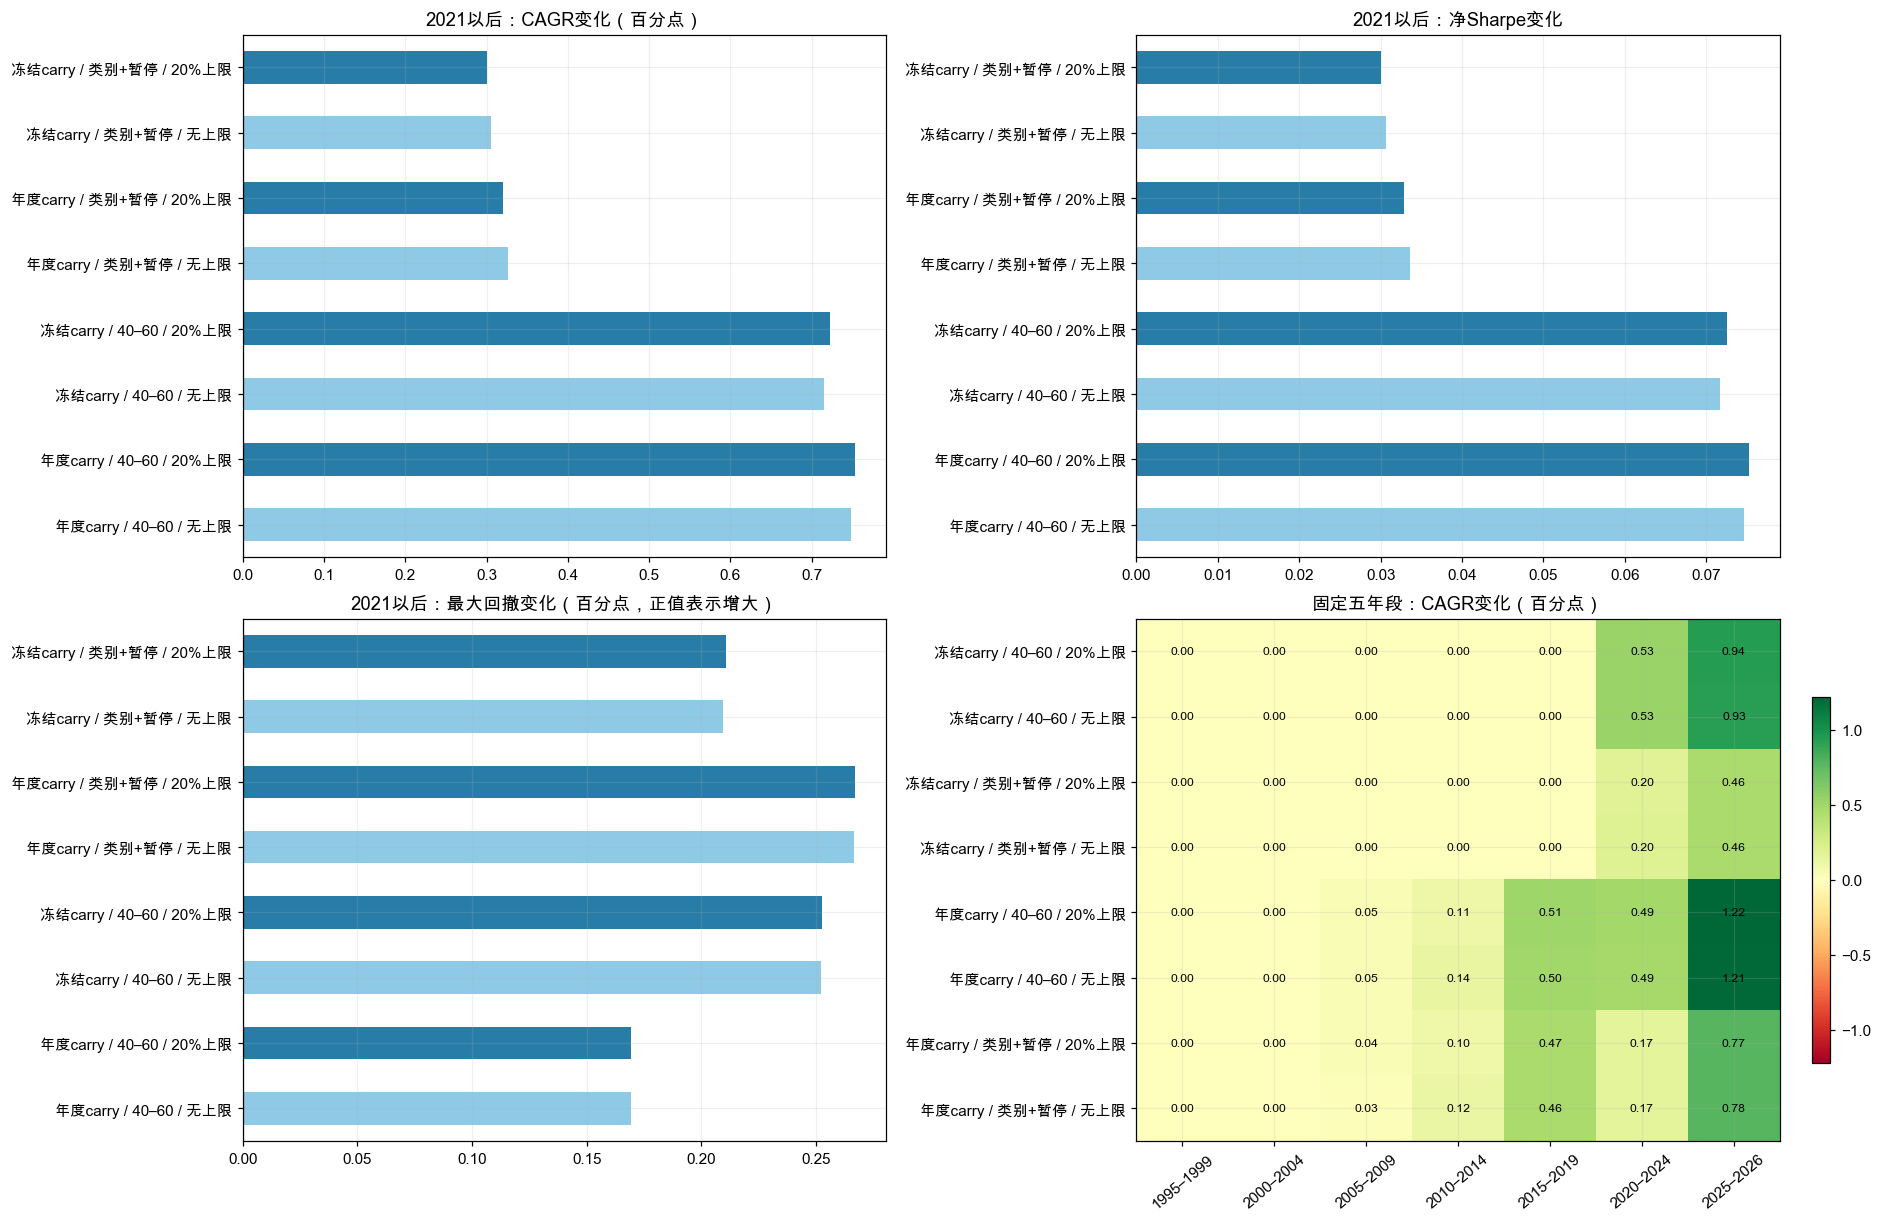

In [35]:
portfolio_labels = {'improved_annual_mixed40':'年度carry / 40–60',
    'improved_frozen_mixed40':'冻结carry / 40–60','improved_annual_fine':'年度carry / 类别+暂停',
    'improved_frozen_fine':'冻结carry / 类别+暂停'}
pair_labels = {}
for policy in improved_policies:
    for cap in ['unlimited','cap20']:
        pause = policy.endswith('_fine')
        pair_labels[str((policy,pause,cap))] = portfolio_labels[policy]+(' / 无上限' if cap=='unlimited' else ' / 20%上限')
carry_pairs['组合'] = carry_pairs.variant.map(pair_labels)
recent_pairs = carry_pairs.loc[carry_pairs.period.eq('2021年以来')].set_index('组合')
fig,axes = plt.subplots(2,2,figsize=(17,11),layout='constrained')
for ax,field,title in zip(axes.ravel()[:3],['cagr_change_pp','sharpe_change','drawdown_change_pp'],
    ['2021以后：CAGR变化（百分点）','2021以后：净Sharpe变化','2021以后：最大回撤变化（百分点，正值表示增大）']):
    recent_pairs[field].plot.barh(ax=ax,color=['#277da8' if '20%' in label else '#8ecae6' for label in recent_pairs.index])
    ax.axvline(0,color='black',lw=.7)
    ax.set_title(title)
    ax.set_ylabel('')
five_years = carry_pairs.loc[carry_pairs.period.str.contains('–')].pivot(index='组合',columns='period',values='cagr_change_pp')
limit = max(five_years.abs().max().max(),.01)
im = axes[1,1].imshow(five_years,aspect='auto',cmap='RdYlGn',vmin=-limit,vmax=limit)
axes[1,1].set_xticks(range(len(five_years.columns)),five_years.columns,rotation=40)
axes[1,1].set_yticks(range(len(five_years)),five_years.index)
for (row,column),value in np.ndenumerate(five_years.to_numpy()):
    axes[1,1].text(column,row,f'{value:.2f}',ha='center',va='center',fontsize=8)
axes[1,1].set_title('固定五年段：CAGR变化（百分点）')
fig.colorbar(im,ax=axes[1,1],shrink=.7)
fig.savefig(RUN_ROOT/'figures/final_portfolio_diagnostics.png',dpi=120)
plt.show()


In [38]:
agri_support = folds.loc[folds.decision_year.eq(2021)&folds.broad.eq('农产品')&folds.accepted].copy()
agri_support['品种'] = [classification.loc[code,'Description'] for code in agri_support.economic_id]
display(agri_support[['品种','economic_id','train_observations','valid_observations']])
agri_scores = selection.loc[selection.decision_year.eq(2021)&selection.broad.eq('农产品')].set_index('candidate')
recent = portfolio_results.loc[portfolio_results.period.eq('2021年以来')&portfolio_results.cap.eq('cap20')].set_index('policy')
recent_ci = portfolio_bootstrap.loc[portfolio_bootstrap.period.eq('2021年以来')&
    portfolio_bootstrap.variant.str.contains('improved_',regex=False)].set_index('variant')
assert len(recent_ci)==8
annual_ci = recent_ci.loc[str(('improved_annual_mixed40',False,'cap20'))]
fine_ci = recent_ci.loc[str(('improved_annual_fine',True,'cap20'))]
final_conclusion = f"""## 农产品证据与最终采用判断

农产品的2020年末选择使用9个共同合格经济市场。2011—2017年训练中，基准净Sharpe为{agri_scores.loc['baseline','train_sharpe']:.3f}，月份组合100%调整为{agri_scores.loc['pair100','train_sharpe']:.3f}；2018—2020年验证中分别为{agri_scores.loc['baseline','validate_sharpe']:.3f}、{agri_scores.loc['pair100','validate_sharpe']:.3f}，净现金收益为{agri_scores.loc['baseline','validate_return']:.2f}、{agri_scores.loc['pair100','validate_return']:.2f}百分点。该候选通过预先写定的训练优势、正验证收益与验证Sharpe优势门槛。季节模型保留长期均值，调整的是有历史支持的交易月及交割月份组合。已失效的黄大豆一号观察账户不在上述9市场评分集中。

以20%单品种敞口上限、40% carry / 60% breakout为例，2021年以来基准CAGR为{recent.loc['mixed40','cagr']:.2f}%、Sharpe为{recent.loc['mixed40','sharpe']:.3f}。年度carry方案为{recent.loc['improved_annual_mixed40','cagr']:.2f}%、{recent.loc['improved_annual_mixed40','sharpe']:.3f}；冻结方案为{recent.loc['improved_frozen_mixed40','cagr']:.2f}%、{recent.loc['improved_frozen_mixed40','sharpe']:.3f}。年度方案的CAGR增量95%按年重抽样区间为[{annual_ci.low:.2f}, {annual_ci.high:.2f}]个百分点。最大回撤从{recent.loc['mixed40','max_dd']:.2f}%增至年度方案的{recent.loc['improved_annual_mixed40','max_dd']:.2f}%、冻结方案的{recent.loc['improved_frozen_mixed40','max_dd']:.2f}%。收益增量伴随略高的风险和成本。

类别比例与动态暂停同时启用后，20%上限基准CAGR为{recent.loc['fine_annual','cagr']:.2f}%，新增年度carry方案为{recent.loc['improved_annual_fine','cagr']:.2f}%。CAGR增量区间为[{fine_ci.low:.2f}, {fine_ci.high:.2f}]个百分点，包含0；最大回撤从{recent.loc['fine_annual','max_dd']:.2f}%增至{recent.loc['improved_annual_fine','max_dd']:.2f}%。这套综合方案的新增carry效果仍有较大不确定性。

固定五年段的CAGR变化表保留了早期零变化和后期增量，冻结方案从2021年开始生效。重抽样使用seed=20260907、2000次、2.5%和97.5%分位；2021后只有6个年度块，包含2026部分年度，每次重抽样沿用已生成的规则和成交路径。区间描述本次已实现路径的不确定性。

本轮可以保留农产品月份组合调整作为40/60组合的一项小幅改进，年度与冻结结果接近。类别比例和动态暂停已经启用时，继续保留原方案作为主要基线更稳妥。全品种统一改快、改慢或去季节性的证据有限；逐品种亏损说明和未改善结果继续保留。"""
display(Markdown(final_conclusion))
_ = (RUN_ROOT/'final_conclusion.md').write_text(final_conclusion,encoding='utf-8')


,品种,economic_id,train_observations,valid_observations
2190,郑商所棉花,CZCE_CF,1702,730
2195,郑商所菜籽油,CZCE_OI,1438,719
2197,郑商所菜籽粕,CZCE_RM,1023,715
2199,郑商所白糖,CZCE_SR,1701,728
2204,大商所玉米,DCE_C,1702,730
2206,大商所鸡蛋,DCE_JD,789,730
2208,大商所豆粕,DCE_M,1702,730
2209,大商所棕榈油,DCE_P,1702,730
2211,大商所豆油,DCE_Y,1702,730


## 农产品证据与最终采用判断

农产品的2020年末选择使用9个共同合格经济市场。2011—2017年训练中，基准净Sharpe为0.809，月份组合100%调整为0.940；2018—2020年验证中分别为-0.042、0.412，净现金收益为-1.02、9.64百分点。该候选通过预先写定的训练优势、正验证收益与验证Sharpe优势门槛。季节模型保留长期均值，调整的是有历史支持的交易月及交割月份组合。已失效的黄大豆一号观察账户不在上述9市场评分集中。

以20%单品种敞口上限、40% carry / 60% breakout为例，2021年以来基准CAGR为6.23%、Sharpe为0.758。年度carry方案为6.98%、0.833；冻结方案为6.95%、0.830。年度方案的CAGR增量95%按年重抽样区间为[0.28, 1.25]个百分点。最大回撤从13.16%增至年度方案的13.33%、冻结方案的13.41%。收益增量伴随略高的风险和成本。

类别比例与动态暂停同时启用后，20%上限基准CAGR为6.79%，新增年度carry方案为7.11%。CAGR增量区间为[-0.08, 0.77]个百分点，包含0；最大回撤从13.96%增至14.22%。这套综合方案的新增carry效果仍有较大不确定性。

固定五年段的CAGR变化表保留了早期零变化和后期增量，冻结方案从2021年开始生效。重抽样使用seed=20260907、2000次、2.5%和97.5%分位；2021后只有6个年度块，包含2026部分年度，每次重抽样沿用已生成的规则和成交路径。区间描述本次已实现路径的不确定性。

本轮可以保留农产品月份组合调整作为40/60组合的一项小幅改进，年度与冻结结果接近。类别比例和动态暂停已经启用时，继续保留原方案作为主要基线更稳妥。全品种统一改快、改慢或去季节性的证据有限；逐品种亏损说明和未改善结果继续保留。